COMPLETE DISASTER DAMAGE DETECTION FRAMEWORK
All 9 Classical Methods + Advanced Techniques + Alignment

📁 Dataset Structure Verification:
  hold     - Images: ✓  Masks: ✓
  test     - Images: ✓  Masks: ✓
  tier1    - Images: ✓  Masks: ✓
  tier3    - Images: ✓  Masks: ✓
  train    - Images: ✓  Masks: ✗

✓ Step 1: Dataset paths configured
✓ Step 2: Enhanced Dataset class defined
✓ Step 3: Complete Detector with ALL 9+3 methods defined
✓ Step 4: Metrics & Visualization ready

CREATING DATASETS
  ✓ Loaded 933 pre/post pairs for 'test' (alignment=True)

RUNNING COMPLETE ANALYSIS (ALL 9+3 METHODS)

Sample 1/3: guatemala-volcano_00000003
  Running all 9 classical methods...
  Running 3 advanced methods...
  ✓ Saved: complete_analysis_guatemala-volcano_00000003.png


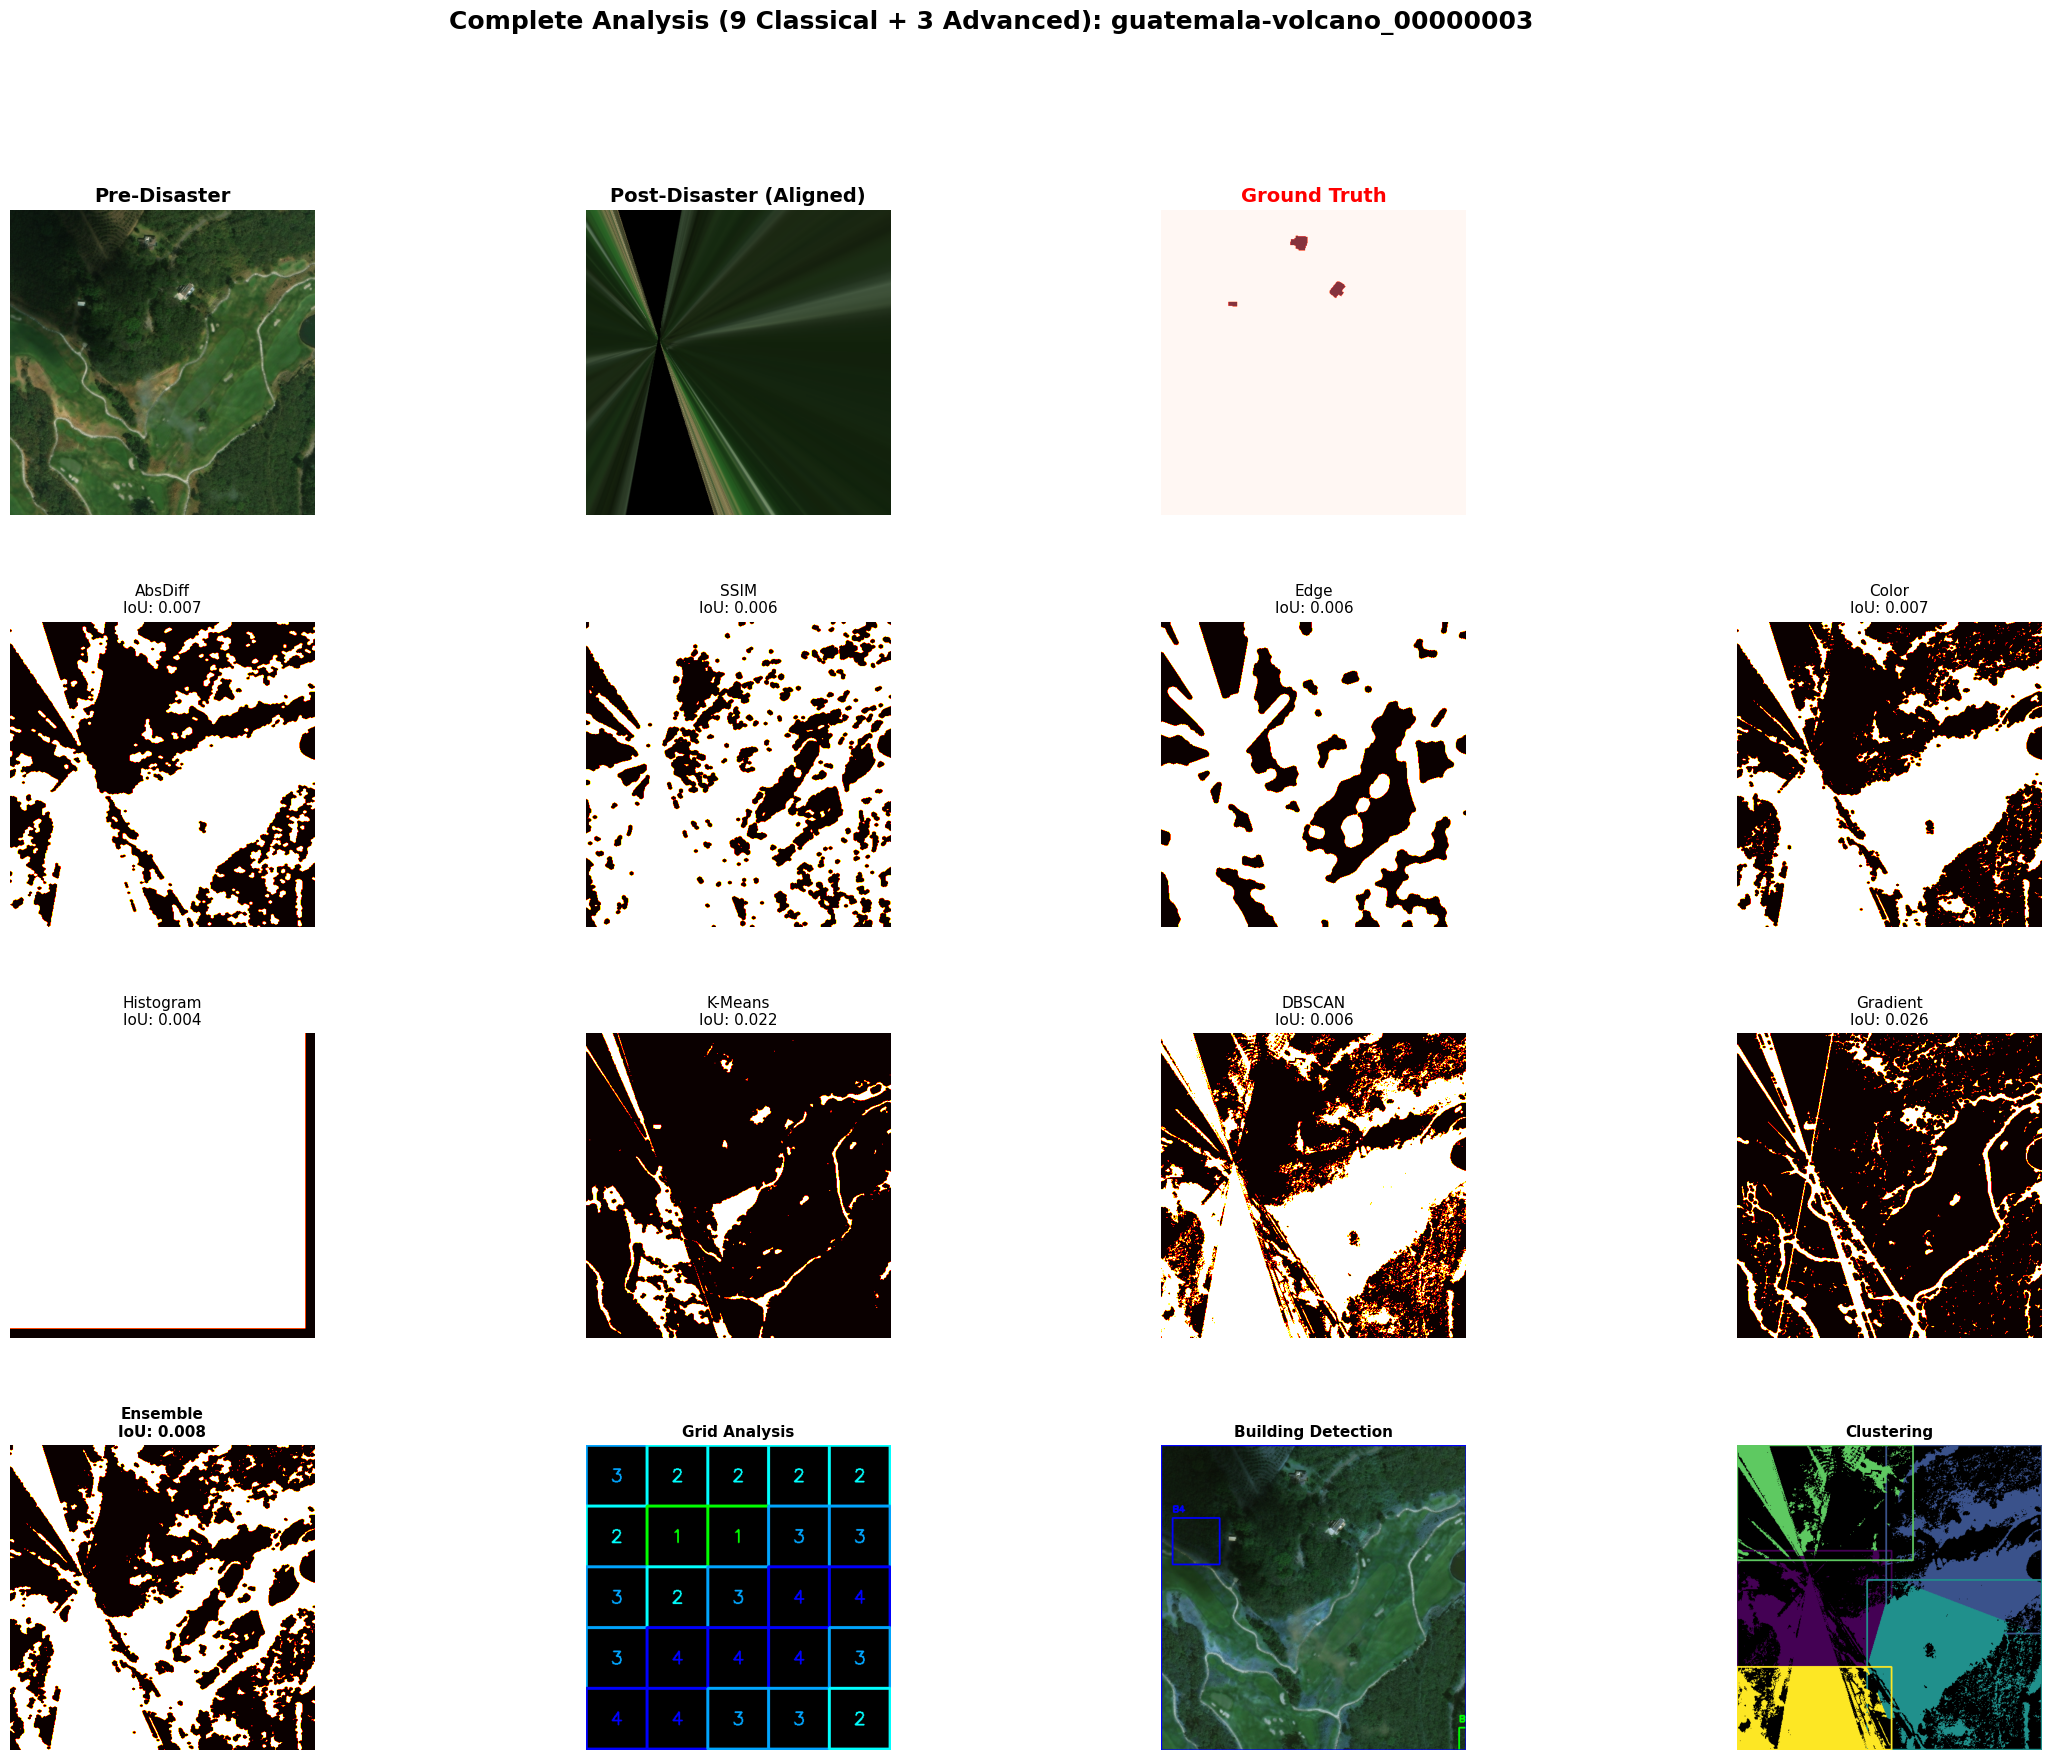


  📊 Grid Analysis:


,region,damage_score,level
0,A1,57.0%,3
1,A2,43.4%,2
2,A3,30.6%,2
3,A4,42.0%,2
4,A5,48.3%,2
5,B1,32.5%,2
6,B2,22.3%,1
7,B3,22.8%,1
8,B4,50.8%,3
9,B5,64.3%,3



  🏢 Building Analysis:


,building_id,area_pixels,damage_ratio,status
0,B1,233,14.2%,Minor
1,B4,549,90.9%,Severe
2,B10,244768,62.9%,Severe



  🎯 Cluster Analysis:


,cluster_id,pixels,damage_pct
0,C1,20579,15.7%
1,C2,31633,24.2%
2,C3,39083,29.9%
3,C4,14076,10.8%
4,C5,25461,19.5%



Sample 2/3: guatemala-volcano_00000005
  Running all 9 classical methods...
  Running 3 advanced methods...
  ✓ Saved: complete_analysis_guatemala-volcano_00000005.png


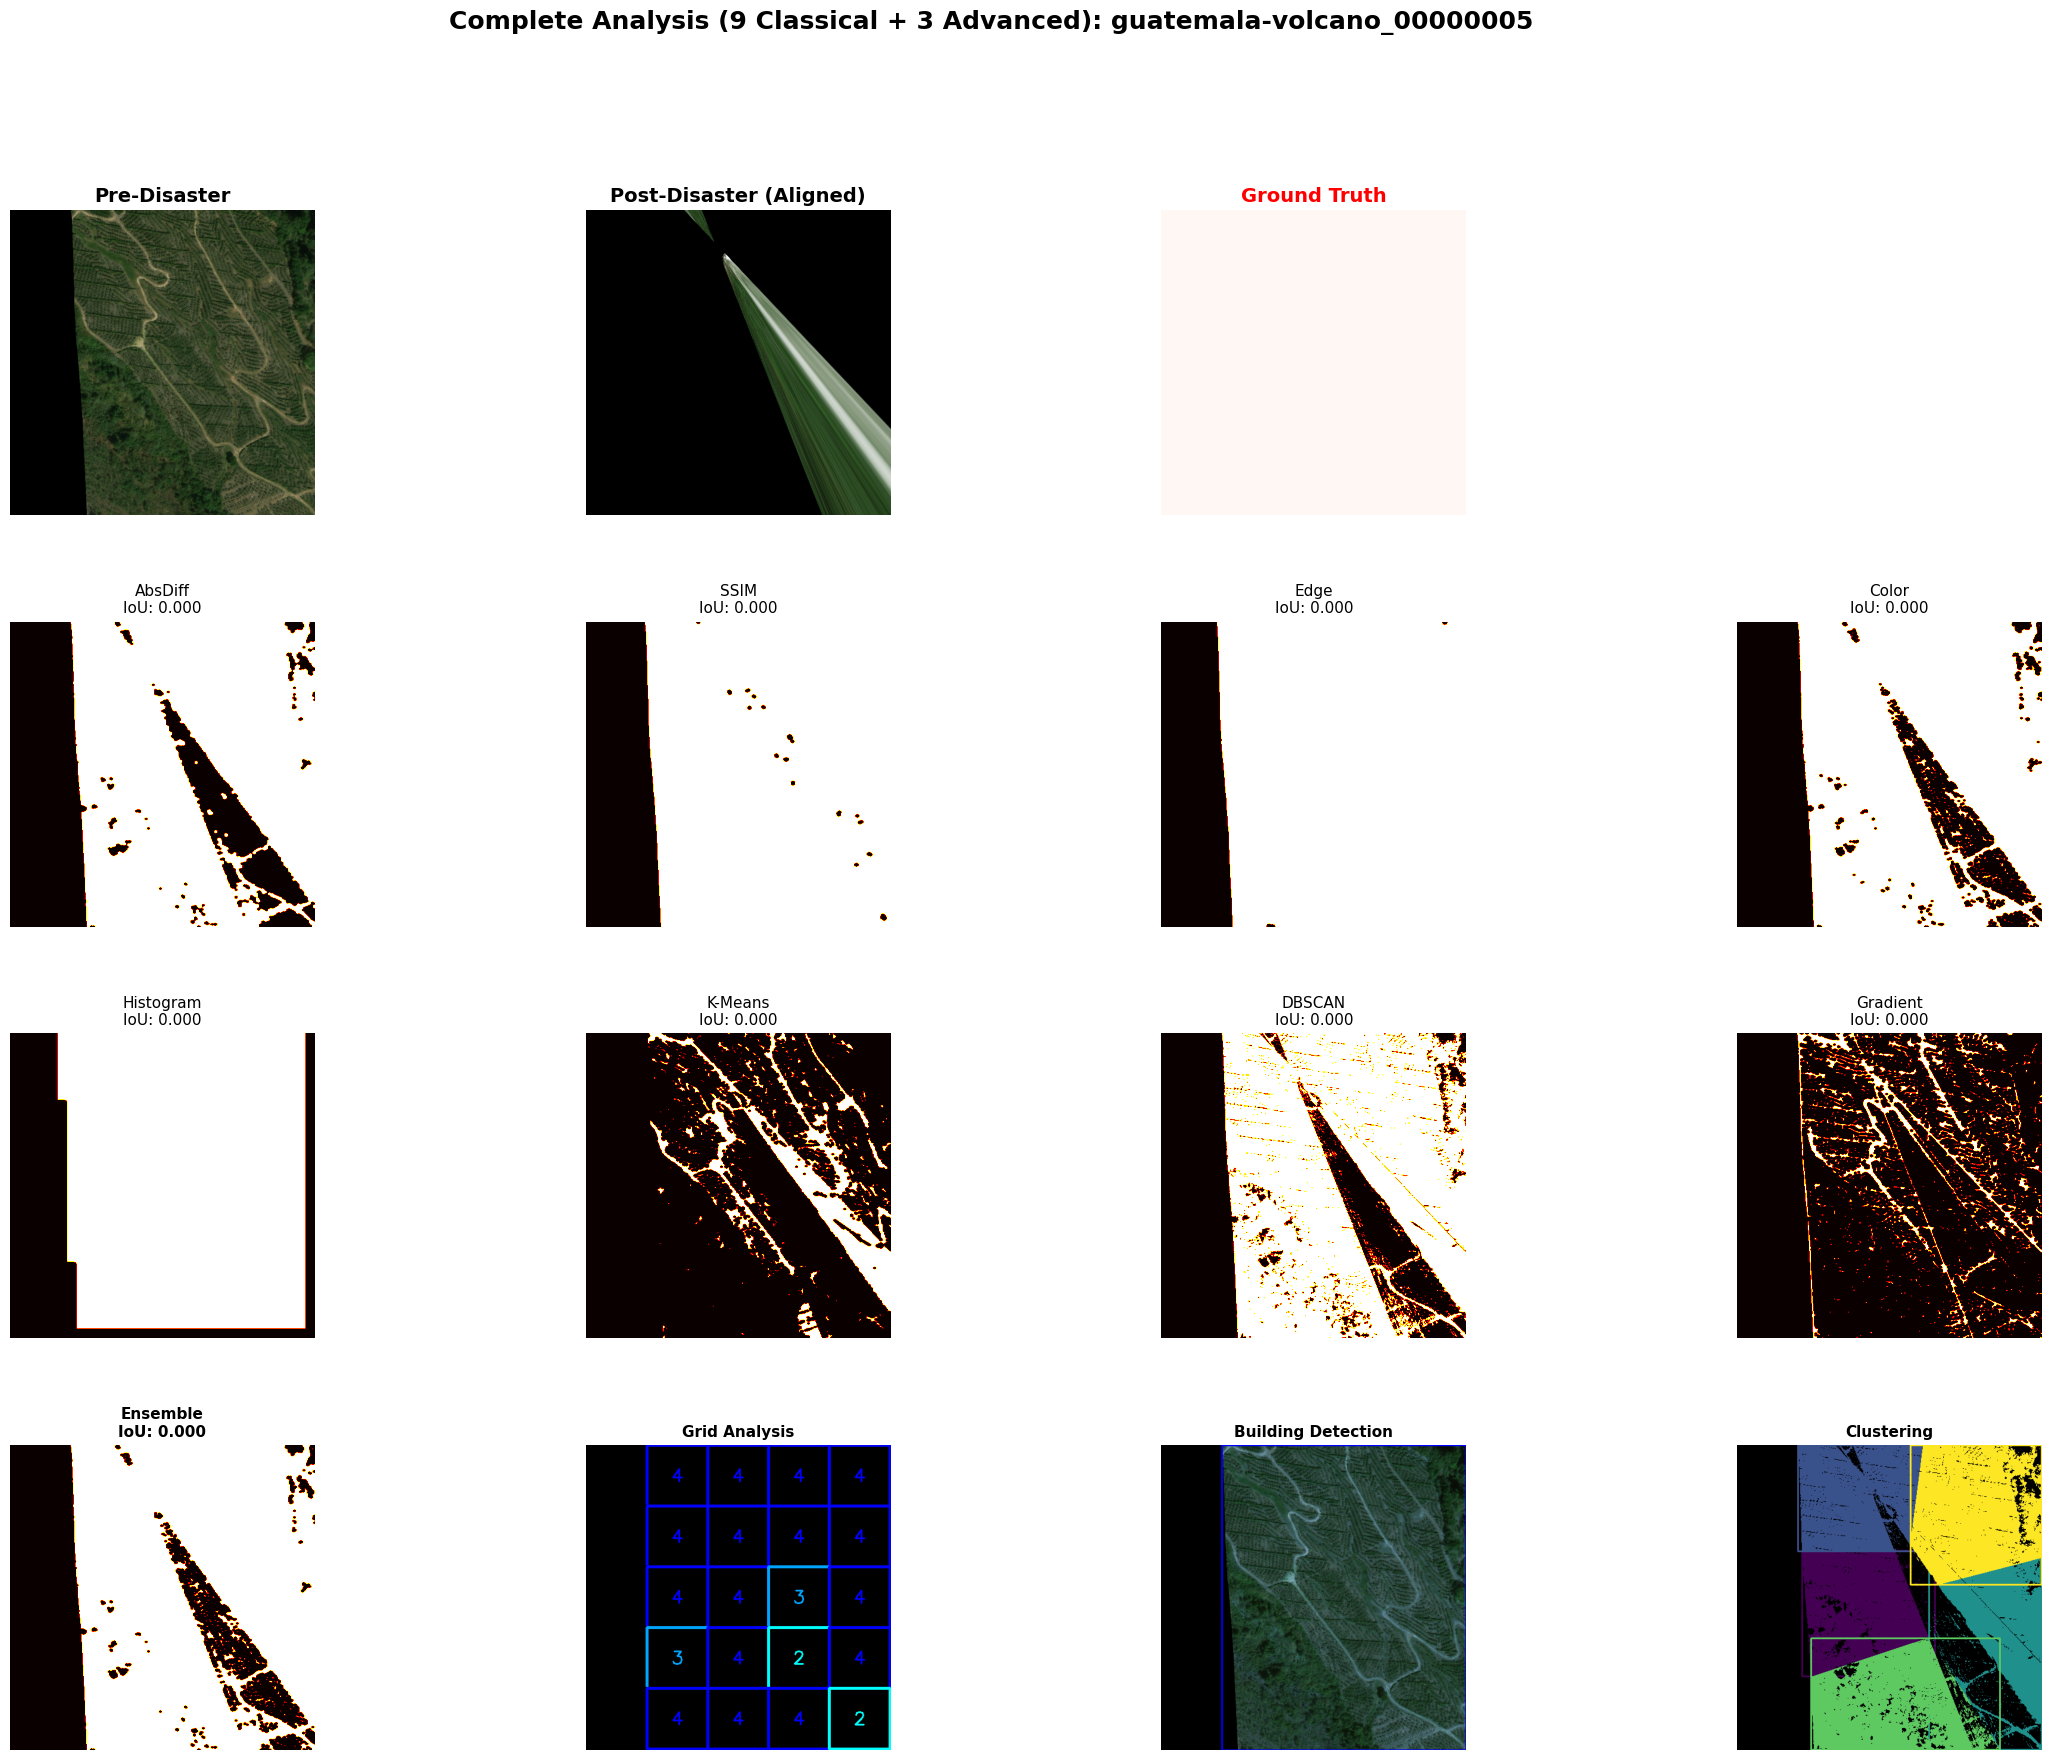


  📊 Grid Analysis:


,region,damage_score,level
0,A1,0.0%,0
1,A2,92.1%,4
2,A3,97.7%,4
3,A4,99.2%,4
4,A5,81.9%,4
5,B1,0.0%,0
6,B2,93.2%,4
7,B3,79.2%,4
8,B4,99.0%,4
9,B5,96.0%,4



  🏢 Building Analysis:


,building_id,area_pixels,damage_ratio,status
0,B3,201692,86.2%,Severe



  🎯 Cluster Analysis:


,cluster_id,pixels,damage_pct
0,C1,31279,18.7%
1,C2,31671,18.9%
2,C3,26921,16.1%
3,C4,36687,21.9%
4,C5,40780,24.4%



Sample 3/3: guatemala-volcano_00000009
  Running all 9 classical methods...
  Running 3 advanced methods...
  ✓ Saved: complete_analysis_guatemala-volcano_00000009.png


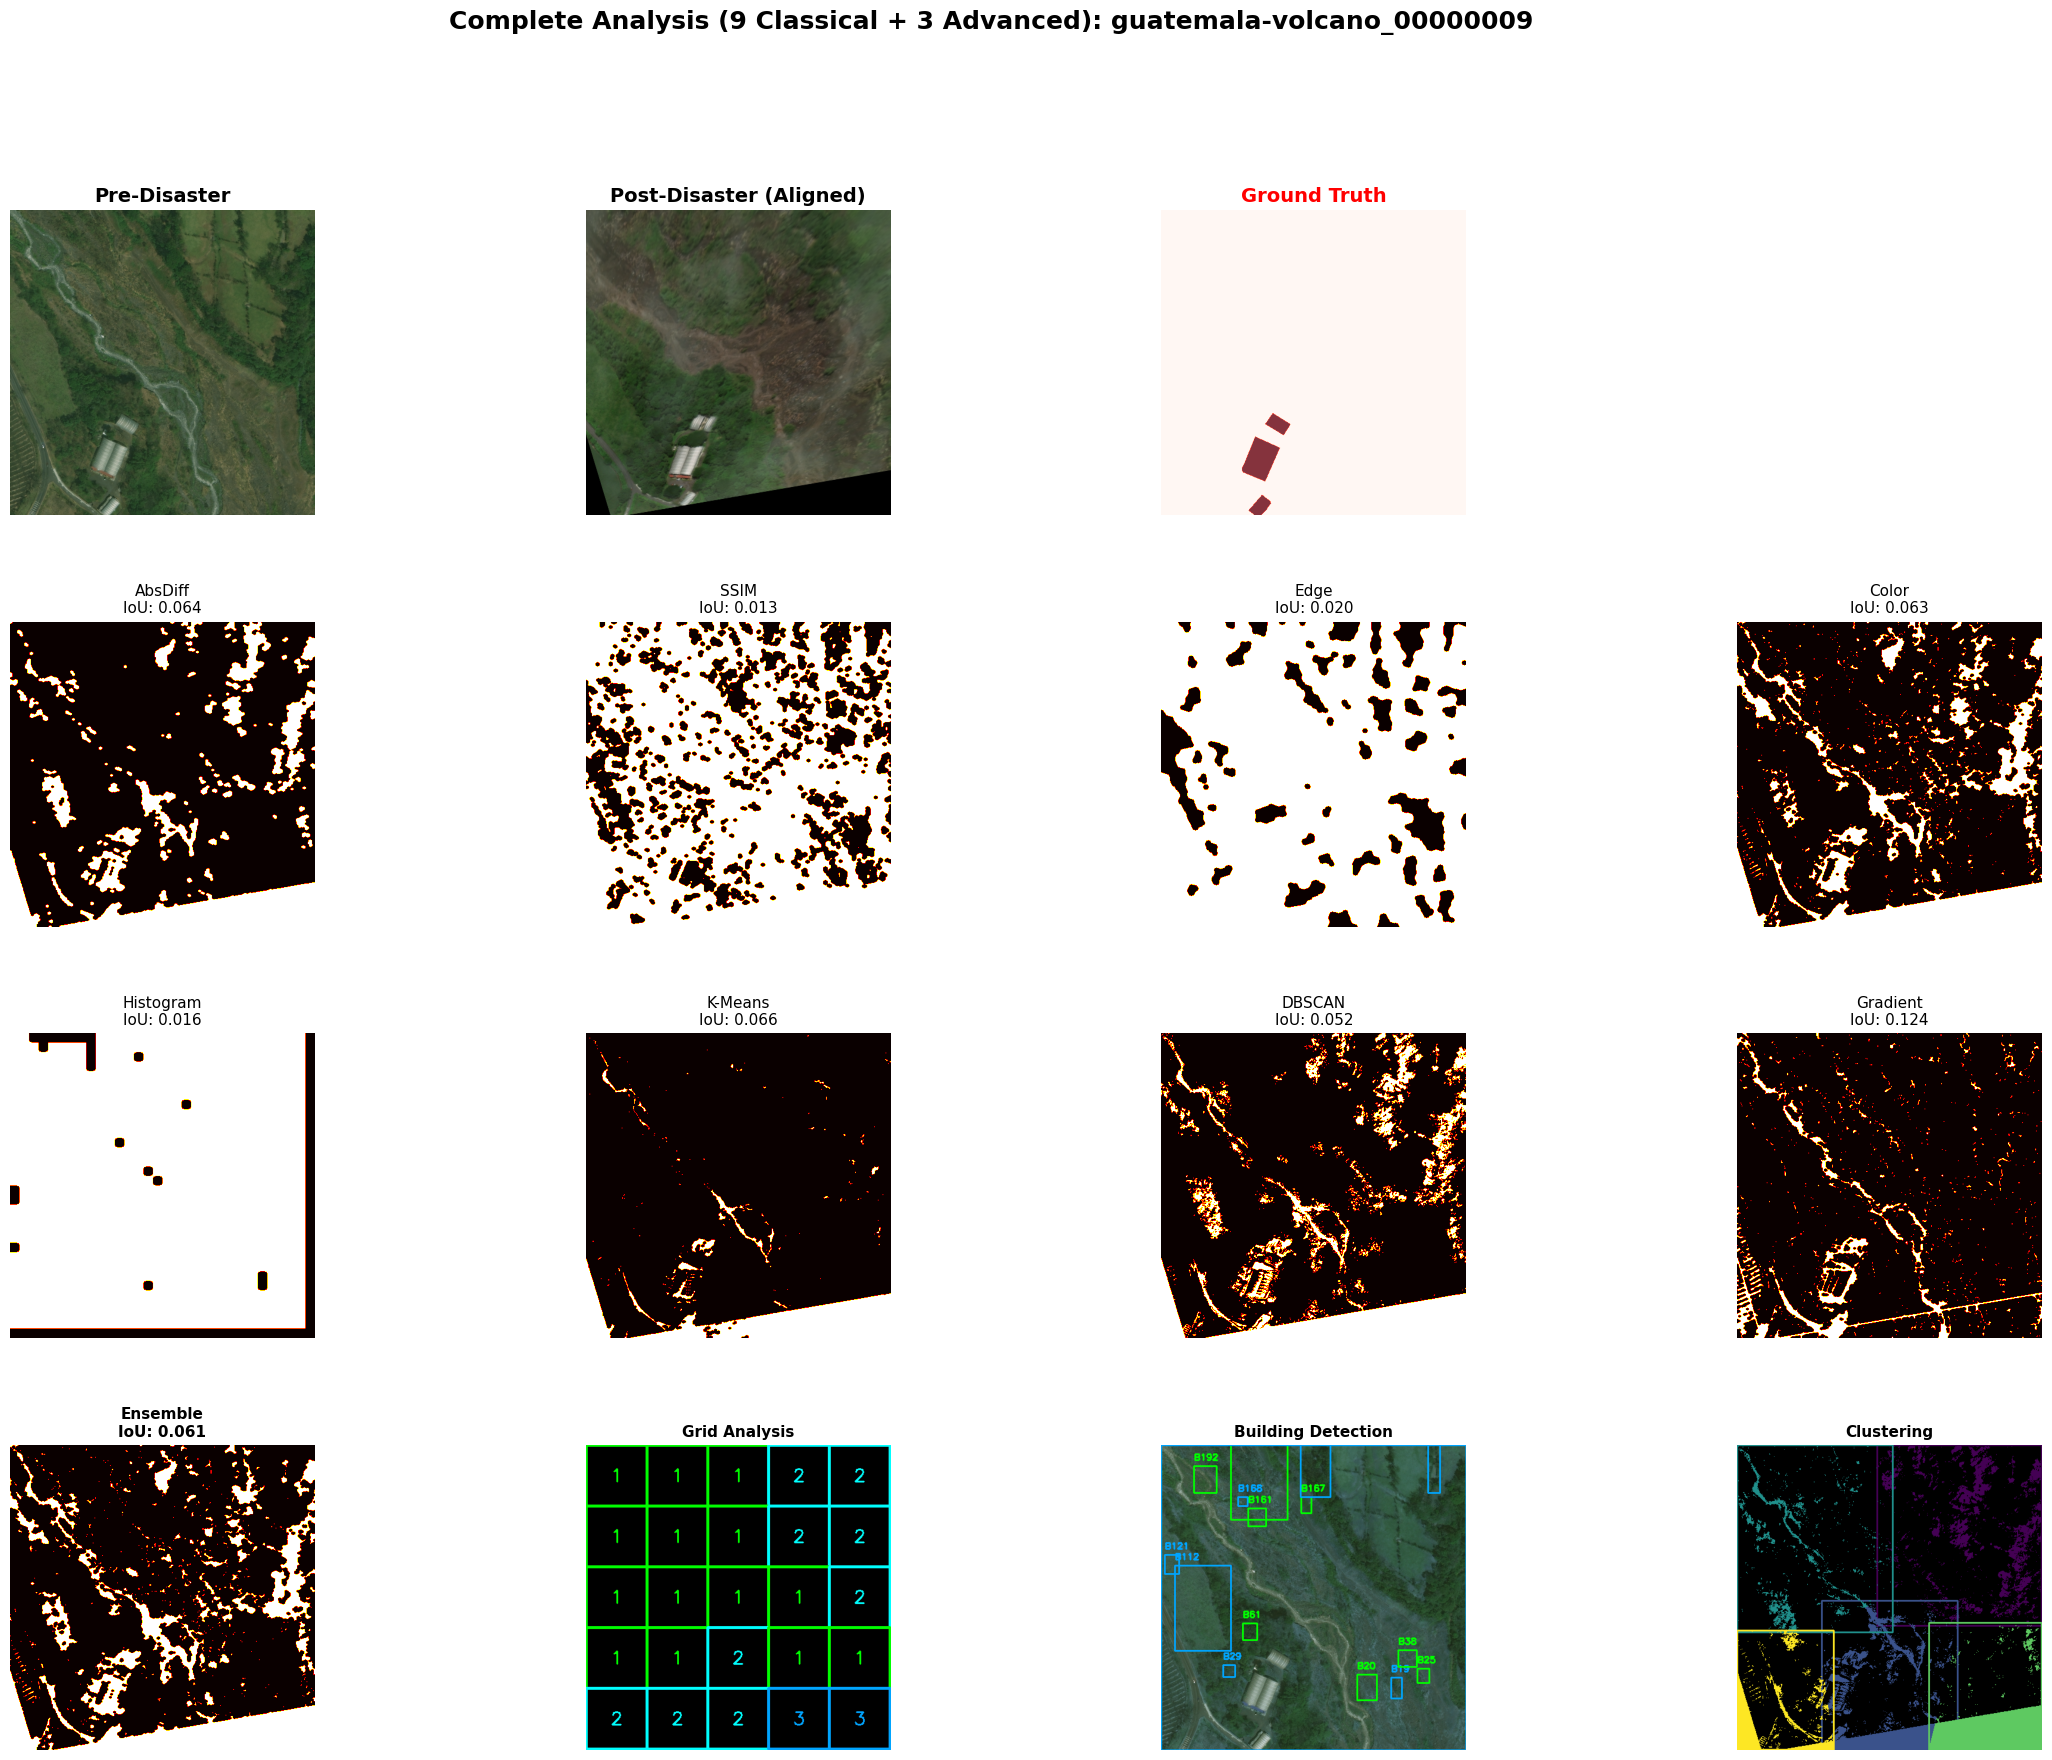


  📊 Grid Analysis:


,region,damage_score,level
0,A1,12.9%,1
1,A2,7.7%,1
2,A3,19.2%,1
3,A4,34.5%,2
4,A5,27.2%,2
5,B1,15.9%,1
6,B2,9.2%,1
7,B3,8.4%,1
8,B4,30.2%,2
9,B5,30.1%,2



  🏢 Building Analysis:


,building_id,area_pixels,damage_ratio,status
0,B19,192,40.1%,Moderate
1,B20,428,28.5%,Minor
2,B25,190,24.7%,Minor
3,B29,211,53.1%,Moderate
4,B38,234,27.8%,Minor
5,B61,225,21.3%,Minor
6,B112,5712,52.2%,Moderate
7,B121,234,33.8%,Moderate
8,B161,188,24.5%,Minor
9,B167,180,29.4%,Minor



  🎯 Cluster Analysis:


,cluster_id,pixels,damage_pct
0,C1,12379,26.4%
1,C2,11509,24.6%
2,C3,5043,10.8%
3,C4,11917,25.5%
4,C5,5958,12.7%



✅ COMPLETE ANALYSIS FINISHED!

📊 Summary:
  ✓ 9 Classical CV Methods
  ✓ 3 Advanced Methods (Grid, Contour, Clustering)
  ✓ Image Alignment (ORB)
  ✓ Publication-Quality Visualizations
  ✓ Structured DataFrames


In [5]:
# =============================================================================
# COMPLETE ENHANCED CODE - ALL FEATURES INCLUDED
# =============================================================================

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Advanced Methods
from skimage.metrics import structural_similarity as ssim
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
from scipy import ndimage

print("="*80)
print("COMPLETE DISASTER DAMAGE DETECTION FRAMEWORK")
print("All 9 Classical Methods + Advanced Techniques + Alignment")
print("="*80)

# =============================================================================
# STEP 1: DATASET PATH CONFIGURATION
# =============================================================================

ROOT_PATH = "/kaggle/input/xbd-dataset/xbd"

split_paths = {
    'hold': {
        'images': os.path.join(ROOT_PATH, 'hold', 'images'),
        'labels': os.path.join(ROOT_PATH, 'hold', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'hold', 'masks')
    },
    'test': {
        'images': os.path.join(ROOT_PATH, 'test', 'images'),
        'labels': os.path.join(ROOT_PATH, 'test', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'test', 'masks')
    },
    'tier1': {
        'images': os.path.join(ROOT_PATH, 'tier1', 'images'),
        'labels': os.path.join(ROOT_PATH, 'tier1', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'tier1', 'masks')
    },
    'tier3': {
        'images': os.path.join(ROOT_PATH, 'tier3', 'images'),
        'labels': os.path.join(ROOT_PATH, 'tier3', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'tier3', 'masks')
    },
    'train': {
        'images': os.path.join(ROOT_PATH, 'train', 'images'),
        'labels': None,
        'masks': None
    }
}

print("\n📁 Dataset Structure Verification:")
for split, paths in split_paths.items():
    img_exists = os.path.exists(paths['images']) if paths['images'] else False
    mask_exists = os.path.exists(paths['masks']) if paths['masks'] else False
    print(f"  {split:8s} - Images: {'✓' if img_exists else '✗'}  Masks: {'✓' if mask_exists else '✗'}")

print("\n✓ Step 1: Dataset paths configured")

# =============================================================================
# STEP 2: ENHANCED DATASET WITH IMAGE ALIGNMENT
# =============================================================================

class EnhancedXBDDataset(Dataset):
    """Enhanced dataset with pre/post pairing and automatic alignment"""
    
    def __init__(self, split='tier1', split_paths=None, img_size=512, align_images=True):
        self.split = split
        self.img_dir = split_paths[split]['images']
        self.mask_dir = split_paths[split]['masks']
        self.img_size = img_size
        self.align_images = align_images
        
        post_images = sorted(glob.glob(os.path.join(self.img_dir, '*_post_disaster.png')))
        
        self.samples = []
        for post_path in post_images:
            pre_path = post_path.replace('_post_disaster.png', '_pre_disaster.png')
            
            if os.path.exists(pre_path):
                base = os.path.basename(post_path).replace('_post_disaster.png', '')
                mask_path = None
                if self.mask_dir:
                    candidate = os.path.join(self.mask_dir, f'{base}_post_disaster.png')
                    if os.path.exists(candidate):
                        mask_path = candidate
                
                self.samples.append({
                    'pre': pre_path,
                    'post': post_path,
                    'mask': mask_path,
                    'id': base
                })
        
        print(f"  ✓ Loaded {len(self.samples)} pre/post pairs for '{split}' (alignment={align_images})")
    
    def align_images_orb(self, pre_img, post_img):
        """Align post-disaster image using ORB feature matching"""
        try:
            pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
            post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
            
            orb = cv2.ORB_create(5000)
            kp1, des1 = orb.detectAndCompute(pre_gray, None)
            kp2, des2 = orb.detectAndCompute(post_gray, None)
            
            if des1 is None or des2 is None:
                return post_img
            
            matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            matches = matcher.match(des1, des2)
            matches = sorted(matches, key=lambda x: x.distance)
            
            if len(matches) < 4:
                return post_img
            
            pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
            pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
            
            H, _ = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
            if H is not None:
                aligned_post = cv2.warpPerspective(post_img, H, (pre_img.shape[1], pre_img.shape[0]))
                return aligned_post
            else:
                return post_img
        except:
            return post_img
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        pre_img = cv2.imread(sample['pre'])
        pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)
        pre_img = cv2.resize(pre_img, (self.img_size, self.img_size))
        
        post_img = cv2.imread(sample['post'])
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)
        post_img = cv2.resize(post_img, (self.img_size, self.img_size))
        
        if self.align_images:
            post_img = self.align_images_orb(pre_img, post_img)
        
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        if sample['mask']:
            mask = cv2.imread(sample['mask'], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size, self.img_size))
            mask = (mask > 0).astype(np.uint8)
        
        return pre_img, post_img, mask, sample['id']

print("✓ Step 2: Enhanced Dataset class defined")

# =============================================================================
# STEP 3: COMPLETE DAMAGE DETECTION CLASS (ALL 9 METHODS + ADVANCED)
# =============================================================================

class CompleteDamageDetector:
    """
    Complete implementation with:
    - 9 Classical CV methods
    - 3 Advanced methods (Grid, Contour, Clustering)
    - Full analysis capabilities
    """
    
    def __init__(self):
        self.results = {}
    
    # =========================================================================
    # CLASSICAL METHOD 1: Absolute Difference
    # =========================================================================
    def method_1_absolute_difference(self, pre_img, post_img, threshold=30):
        """Pixel-wise intensity change detection"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        diff = cv2.absdiff(pre_gray, post_gray)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 2: SSIM
    # =========================================================================
    def method_2_ssim(self, pre_img, post_img, threshold=0.5):
        """Structural similarity-based detection"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        score, diff = ssim(pre_gray, post_gray, full=True)
        diff = (1 - diff) * 255
        diff = diff.astype(np.uint8)
        _, mask = cv2.threshold(diff, int(threshold * 255), 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 3: Edge Detection
    # =========================================================================
    def method_3_edge_detection(self, pre_img, post_img):
        """Canny edge-based change detection"""
        pre_edges = cv2.Canny(pre_img, 50, 150)
        post_edges = cv2.Canny(post_img, 50, 150)
        edge_diff = cv2.absdiff(pre_edges, post_edges)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.dilate(edge_diff, kernel, iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 4: Color Change
    # =========================================================================
    def method_4_color_change(self, pre_img, post_img, threshold=40):
        """Multi-channel RGB change detection"""
        diff_r = cv2.absdiff(pre_img[:,:,0], post_img[:,:,0])
        diff_g = cv2.absdiff(pre_img[:,:,1], post_img[:,:,1])
        diff_b = cv2.absdiff(pre_img[:,:,2], post_img[:,:,2])
        diff = np.maximum(np.maximum(diff_r, diff_g), diff_b)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 5: Histogram-based
    # =========================================================================
    def method_5_histogram(self, pre_img, post_img, threshold=0.3):
        """Local histogram comparison for texture changes"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        
        h, w = pre_gray.shape
        mask = np.zeros((h, w), dtype=np.uint8)
        
        window_size = 32
        stride = 16
        
        for y in range(0, h - window_size, stride):
            for x in range(0, w - window_size, stride):
                pre_patch = pre_gray[y:y+window_size, x:x+window_size]
                post_patch = post_gray[y:y+window_size, x:x+window_size]
                
                hist_pre = cv2.calcHist([pre_patch], [0], None, [256], [0, 256])
                hist_post = cv2.calcHist([post_patch], [0], None, [256], [0, 256])
                
                hist_pre = hist_pre / hist_pre.sum()
                hist_post = hist_post / hist_post.sum()
                
                similarity = cv2.compareHist(hist_pre, hist_post, cv2.HISTCMP_BHATTACHARYYA)
                
                if similarity > threshold:
                    mask[y:y+window_size, x:x+window_size] = 255
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 6: K-Means Clustering
    # =========================================================================
    def method_6_kmeans(self, pre_img, post_img, n_clusters=3):
        """K-Means clustering on difference image"""
        diff = cv2.absdiff(pre_img, post_img).astype(np.float32)
        h, w, c = diff.shape
        pixels = diff.reshape(-1, 3)
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels)
        labels = labels.reshape(h, w)
        cluster_means = [pixels[labels.flatten() == i].mean() for i in range(n_clusters)]
        damage_cluster = np.argmax(cluster_means)
        mask = (labels == damage_cluster).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return mask
    
    # =========================================================================
    # CLASSICAL METHOD 7: DBSCAN Clustering
    # =========================================================================
    def method_7_dbscan(self, pre_img, post_img, eps=10, min_samples=50):
        """Density-based spatial clustering"""
        diff = cv2.absdiff(
            cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY),
            cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        )
        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        coords = np.column_stack(np.where(thresh > 0))
        
        if len(coords) < min_samples:
            return np.zeros(diff.shape, dtype=np.uint8)
        
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
        mask = np.zeros(diff.shape, dtype=np.uint8)
        
        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            cluster_coords = coords[clustering.labels_ == cluster_id]
            mask[cluster_coords[:, 0], cluster_coords[:, 1]] = 1
        
        return mask
    
    # =========================================================================
    # CLASSICAL METHOD 8: Gradient-based
    # =========================================================================
    def method_8_gradient(self, pre_img, post_img, threshold=30):
        """Gradient magnitude change detection"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        
        pre_grad_x = cv2.Sobel(pre_gray, cv2.CV_64F, 1, 0, ksize=3)
        pre_grad_y = cv2.Sobel(pre_gray, cv2.CV_64F, 0, 1, ksize=3)
        pre_grad_mag = np.sqrt(pre_grad_x**2 + pre_grad_y**2)
        
        post_grad_x = cv2.Sobel(post_gray, cv2.CV_64F, 1, 0, ksize=3)
        post_grad_y = cv2.Sobel(post_gray, cv2.CV_64F, 0, 1, ksize=3)
        post_grad_mag = np.sqrt(post_grad_x**2 + post_grad_y**2)
        
        grad_diff = np.abs(pre_grad_mag - post_grad_mag)
        grad_diff = (grad_diff / grad_diff.max() * 255).astype(np.uint8)
        
        _, mask = cv2.threshold(grad_diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    # =========================================================================
    # CLASSICAL METHOD 9: Ensemble (Voting)
    # =========================================================================
    def method_9_ensemble(self, pre_img, post_img, voting_threshold=0.4):
        """Ensemble voting from multiple methods"""
        masks = []
        masks.append(self.method_1_absolute_difference(pre_img, post_img))
        masks.append(self.method_2_ssim(pre_img, post_img))
        masks.append(self.method_3_edge_detection(pre_img, post_img))
        masks.append(self.method_4_color_change(pre_img, post_img))
        masks.append(self.method_6_kmeans(pre_img, post_img))
        
        ensemble_mask = np.mean(np.stack(masks), axis=0)
        ensemble_mask = (ensemble_mask > voting_threshold).astype(np.uint8)
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        ensemble_mask = cv2.morphologyEx(ensemble_mask, cv2.MORPH_CLOSE, kernel)
        return ensemble_mask
    
    # =========================================================================
    # ADVANCED METHOD 1: Grid Analysis
    # =========================================================================
    def method_grid_analysis(self, pre_img, post_img, grid_rows=5, grid_cols=5):
        """Grid-based regional damage assessment"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        
        h, w = thresh.shape
        tile_h, tile_w = h // grid_rows, w // grid_cols
        
        damage_scores = np.zeros((grid_rows, grid_cols))
        damage_map = np.zeros((h, w, 3), dtype=np.uint8)
        region_details = []
        
        for r in range(grid_rows):
            for c in range(grid_cols):
                tile = thresh[r*tile_h:(r+1)*tile_h, c*tile_w:(c+1)*tile_w]
                change_pixels = np.sum(tile > 0)
                total_pixels = tile.size
                score = (change_pixels / total_pixels) * 100
                
                damage_scores[r, c] = score
                
                if score > 75:
                    level, color = 4, (255, 0, 0)
                elif score > 50:
                    level, color = 3, (255, 165, 0)
                elif score > 25:
                    level, color = 2, (255, 255, 0)
                elif score > 0:
                    level, color = 1, (0, 255, 0)
                else:
                    level, color = 0, (0, 0, 0)
                
                start_point = (c*tile_w, r*tile_h)
                end_point = ((c+1)*tile_w, (r+1)*tile_h)
                cv2.rectangle(damage_map, start_point, end_point, color, 3)
                cv2.putText(damage_map, str(level), 
                           (c*tile_w + tile_w//2 - 10, r*tile_h + tile_h//2 + 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
                
                region_details.append({
                    'region': f"{chr(65+r)}{c+1}",
                    'damage_score': f"{score:.1f}%",
                    'level': level
                })
        
        return damage_map, damage_scores, pd.DataFrame(region_details)
    
    # =========================================================================
    # ADVANCED METHOD 2: Contour Analysis
    # =========================================================================
    def method_contour_analysis(self, pre_img, post_img, min_area=100):
        """Contour-based individual building assessment"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        
        kernel = np.ones((5, 5), np.uint8)
        merged = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
        
        contours, _ = cv2.findContours(merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        building_data = []
        damage_overlay = pre_img.copy()
        
        for i, contour in enumerate(contours):
            area = cv2.contourArea(contour)
            if area < min_area:
                continue
            
            mask = np.zeros(thresh.shape, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 255, -1)
            
            changed_pixels = np.sum((thresh > 0) & (mask > 0))
            total_pixels = np.sum(mask > 0)
            damage_ratio = changed_pixels / total_pixels if total_pixels > 0 else 0
            
            if damage_ratio > 0.6:
                status, color = "Severe", (255, 0, 0)
            elif damage_ratio > 0.3:
                status, color = "Moderate", (255, 165, 0)
            else:
                status, color = "Minor", (0, 255, 0)
            
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(damage_overlay, (x, y), (x+w, y+h), color, 2)
            cv2.putText(damage_overlay, f"B{i+1}", (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            building_data.append({
                'building_id': f"B{i+1}",
                'area_pixels': total_pixels,
                'damage_ratio': f"{damage_ratio:.1%}",
                'status': status
            })
        
        return damage_overlay, pd.DataFrame(building_data)
    
    # =========================================================================
    # ADVANCED METHOD 3: Intelligent Clustering
    # =========================================================================
    def method_intelligent_clustering(self, pre_img, post_img, n_clusters=5):
        """K-Means clustering of damaged regions"""
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        
        damaged_coords = np.argwhere(thresh > 0)
        
        if len(damaged_coords) == 0 or len(damaged_coords) < n_clusters:
            return np.zeros_like(pre_img), pd.DataFrame()
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(damaged_coords)
        
        clustered_map = np.zeros_like(pre_img)
        cluster_data = []
        
        unique_labels = np.unique(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
        
        for k, col in zip(unique_labels, colors):
            class_mask = (labels == k)
            cluster_coords = damaged_coords[class_mask]
            
            if len(cluster_coords) > 0:
                bgr_color = (int(col[2]*255), int(col[1]*255), int(col[0]*255))
                
                for coord in cluster_coords:
                    clustered_map[coord[0], coord[1]] = bgr_color
                
                num_pixels = len(cluster_coords)
                total_damaged = len(damaged_coords)
                damage_percentage = (num_pixels / total_damaged) * 100
                
                y_min, x_min = np.min(cluster_coords, axis=0)
                y_max, x_max = np.max(cluster_coords, axis=0)
                cv2.rectangle(clustered_map, (x_min, y_min), (x_max, y_max), bgr_color, 2)
                
                cluster_data.append({
                    'cluster_id': f"C{k+1}",
                    'pixels': num_pixels,
                    'damage_pct': f"{damage_percentage:.1f}%"
                })
        
        return clustered_map, pd.DataFrame(cluster_data)
    
    # =========================================================================
    # RUN ALL METHODS
    # =========================================================================
    def run_all_methods(self, pre_img, post_img):
        """Execute ALL 9 classical + 3 advanced methods"""
        results = {}
        
        print("  Running all 9 classical methods...")
        results['Method_1_AbsDiff'] = self.method_1_absolute_difference(pre_img, post_img)
        results['Method_2_SSIM'] = self.method_2_ssim(pre_img, post_img)
        results['Method_3_Edge'] = self.method_3_edge_detection(pre_img, post_img)
        results['Method_4_Color'] = self.method_4_color_change(pre_img, post_img)
        results['Method_5_Histogram'] = self.method_5_histogram(pre_img, post_img)
        results['Method_6_KMeans'] = self.method_6_kmeans(pre_img, post_img)
        results['Method_7_DBSCAN'] = self.method_7_dbscan(pre_img, post_img)
        results['Method_8_Gradient'] = self.method_8_gradient(pre_img, post_img)
        results['Method_9_Ensemble'] = self.method_9_ensemble(pre_img, post_img)
        
        print("  Running 3 advanced methods...")
        grid_map, grid_scores, grid_df = self.method_grid_analysis(pre_img, post_img)
        results['Grid_Map'] = grid_map
        results['Grid_DataFrame'] = grid_df
        
        contour_overlay, contour_df = self.method_contour_analysis(pre_img, post_img)
        results['Contour_Overlay'] = contour_overlay
        results['Contour_DataFrame'] = contour_df
        
        cluster_map, cluster_df = self.method_intelligent_clustering(pre_img, post_img)
        results['Cluster_Map'] = cluster_map
        results['Cluster_DataFrame'] = cluster_df
        
        return results

print("✓ Step 3: Complete Detector with ALL 9+3 methods defined")

# =============================================================================
# STEP 4: METRICS & VISUALIZATION
# =============================================================================

def compute_metrics(pred_mask, true_mask):
    """Compute IoU, Precision, Recall, F1"""
    pred_flat = pred_mask.flatten()
    true_flat = true_mask.flatten()
    
    if pred_flat.sum() == 0 and true_flat.sum() == 0:
        return {'IoU': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}
    
    iou = jaccard_score(true_flat, pred_flat, zero_division=0)
    precision = precision_score(true_flat, pred_flat, zero_division=0)
    recall = recall_score(true_flat, pred_flat, zero_division=0)
    f1 = f1_score(true_flat, pred_flat, zero_division=0)
    
    return {'IoU': iou, 'Precision': precision, 'Recall': recall, 'F1': f1}

def visualize_comprehensive_analysis(pre_img, post_img, gt_mask, results, sample_id):
    """Publication-quality comprehensive visualization"""
    
    fig = plt.figure(figsize=(28, 20))
    gs = fig.add_gridspec(4, 4, hspace=0.35, wspace=0.3)
    
    # Row 1: Inputs
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(pre_img)
    ax1.set_title("Pre-Disaster", fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(post_img)
    ax2.set_title("Post-Disaster (Aligned)", fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.imshow(gt_mask, cmap='Reds', alpha=0.8)
    ax3.set_title("Ground Truth", fontsize=14, fontweight='bold', color='red')
    ax3.axis('off')
    
    # Row 2: Classical methods (first 4)
    classical_methods = [
        ('Method_1_AbsDiff', 'AbsDiff'),
        ('Method_2_SSIM', 'SSIM'),
        ('Method_3_Edge', 'Edge'),
        ('Method_4_Color', 'Color')
    ]
    
    for idx, (key, name) in enumerate(classical_methods):
        ax = fig.add_subplot(gs[1, idx])
        ax.imshow(results[key], cmap='hot')
        iou = compute_metrics(results[key], gt_mask)['IoU']
        ax.set_title(f"{name}\nIoU: {iou:.3f}", fontsize=11)
        ax.axis('off')
    
    # Row 3: Classical methods (next 5)
    classical_methods_2 = [
        ('Method_5_Histogram', 'Histogram'),
        ('Method_6_KMeans', 'K-Means'),
        ('Method_7_DBSCAN', 'DBSCAN'),
        ('Method_8_Gradient', 'Gradient')
    ]
    
    for idx, (key, name) in enumerate(classical_methods_2):
        ax = fig.add_subplot(gs[2, idx])
        ax.imshow(results[key], cmap='hot')
        iou = compute_metrics(results[key], gt_mask)['IoU']
        ax.set_title(f"{name}\nIoU: {iou:.3f}", fontsize=11)
        ax.axis('off')
    
    # Row 4: Advanced methods + Ensemble
    ax_ens = fig.add_subplot(gs[3, 0])
    ax_ens.imshow(results['Method_9_Ensemble'], cmap='hot')
    iou_ens = compute_metrics(results['Method_9_Ensemble'], gt_mask)['IoU']
    ax_ens.set_title(f"Ensemble\nIoU: {iou_ens:.3f}", fontsize=11, fontweight='bold')
    ax_ens.axis('off')
    
    ax_grid = fig.add_subplot(gs[3, 1])
    ax_grid.imshow(cv2.cvtColor(results['Grid_Map'], cv2.COLOR_BGR2RGB))
    ax_grid.set_title("Grid Analysis", fontsize=11, fontweight='bold')
    ax_grid.axis('off')
    
    ax_cont = fig.add_subplot(gs[3, 2])
    ax_cont.imshow(cv2.cvtColor(results['Contour_Overlay'], cv2.COLOR_BGR2RGB))
    ax_cont.set_title("Building Detection", fontsize=11, fontweight='bold')
    ax_cont.axis('off')
    
    ax_clust = fig.add_subplot(gs[3, 3])
    ax_clust.imshow(cv2.cvtColor(results['Cluster_Map'], cv2.COLOR_BGR2RGB))
    ax_clust.set_title("Clustering", fontsize=11, fontweight='bold')
    ax_clust.axis('off')
    
    plt.suptitle(f'Complete Analysis (9 Classical + 3 Advanced): {sample_id}', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    plt.savefig(f'complete_analysis_{sample_id}.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: complete_analysis_{sample_id}.png")
    plt.show()
    
    # Display DataFrames
    print("\n  📊 Grid Analysis:")
    display(results['Grid_DataFrame'].head(10))
    
    if len(results['Contour_DataFrame']) > 0:
        print("\n  🏢 Building Analysis:")
        display(results['Contour_DataFrame'].head(10))
    
    if len(results['Cluster_DataFrame']) > 0:
        print("\n  🎯 Cluster Analysis:")
        display(results['Cluster_DataFrame'])

print("✓ Step 4: Metrics & Visualization ready")

# =============================================================================
# STEP 5: RUN COMPLETE ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("CREATING DATASETS")
print("="*80)

test_dataset_enhanced = EnhancedXBDDataset(
    split='test', 
    split_paths=split_paths, 
    img_size=512, 
    align_images=True
)

complete_detector = CompleteDamageDetector()

print("\n" + "="*80)
print("RUNNING COMPLETE ANALYSIS (ALL 9+3 METHODS)")
print("="*80)

num_samples = min(3, len(test_dataset_enhanced))

for idx in range(num_samples):
    pre_img, post_img, gt_mask, sample_id = test_dataset_enhanced[idx]
    
    print(f"\n{'='*70}")
    print(f"Sample {idx+1}/{num_samples}: {sample_id}")
    print(f"{'='*70}")
    
    results = complete_detector.run_all_methods(pre_img, post_img)
    visualize_comprehensive_analysis(pre_img, post_img, gt_mask, results, sample_id)

print("\n" + "="*80)
print("✅ COMPLETE ANALYSIS FINISHED!")
print("="*80)
print("\n📊 Summary:")
print("  ✓ 9 Classical CV Methods")
print("  ✓ 3 Advanced Methods (Grid, Contour, Clustering)")
print("  ✓ Image Alignment (ORB)")
print("  ✓ Publication-Quality Visualizations")
print("  ✓ Structured DataFrames")


RESEARCH-GRADE DISASTER DAMAGE DETECTION ANALYSIS
Complete Framework with Clean Progress Display

✓ Dataset paths configured
✓ Dataset class defined
✓ Complete Detector defined (9 Classical + 3 Advanced methods)
✓ Metrics computation ready
✓ Evaluation function ready
✓ Statistical analysis ready
✓ Visualization & reporting ready

STARTING COMPREHENSIVE EVALUATION
  ✓ Loaded 933 pairs for 'test'

EVALUATION PARAMETERS
Dataset: test
Total Samples: 933
Evaluating: 933 samples
Image Size: 512x512

🔄 Starting evaluation...
⏱️  Estimated time: ~1-2 hours for 933 samples



Evaluating:  11%|██████▏                                                   | 100/933 [11:16<1:28:32]


✓ 100/933 | ETA: 93.9 min


Evaluating:  21%|████████████▍                                             | 200/933 [23:40<1:34:34]


✓ 200/933 | ETA: 86.8 min


...


✓ 800/933 | ETA: 15.0 min


Evaluating:  96%|███████████████████████████████████████████████████████▉  | 900/933 [1:40:13<03:13]


✓ 900/933 | ETA: 3.7 min


Evaluating: 100%|██████████████████████████████████████████████████████████| 933/933 [1:43:41<00:00]




EVALUATION COMPLETE
✓ Samples: 933
✓ Time: 103.70 min (1.73 hr)
✓ Avg per sample: 6.67 sec


STATISTICAL ANALYSIS

📊 PERFORMANCE METRICS
     Method  IoU_Mean  F1_Mean  Precision_Mean  Recall_Mean  Accuracy_Mean  Time_Mean_ms
 8 Gradient  0.087415 0.146617        0.113931     0.479591       0.773233    402.112164
     3 Edge  0.066289 0.108775        0.066319     0.790475       0.207715    402.112164
 9 Ensemble  0.061347 0.104560        0.079772     0.492842       0.612427    402.112164
5 Histogram  0.061242 0.101426        0.063050     0.707505       0.189217    402.112164
     2 SSIM  0.059925 0.100347        0.064113     0.641859       0.304934    402.112164
    4 Color  0.059321 0.101446        0.079715     0.471511       0.614611    402.112164
  1 AbsDiff  0.058490 0.099639        0.079758     0.455327       0.614237    402.112164
   7 DBSCAN  0.051216 0.089368        0.076097     0.375004       0.642808    402.112164
   6 KMeans  0.045142 0.081768        0.102099     0.224804 

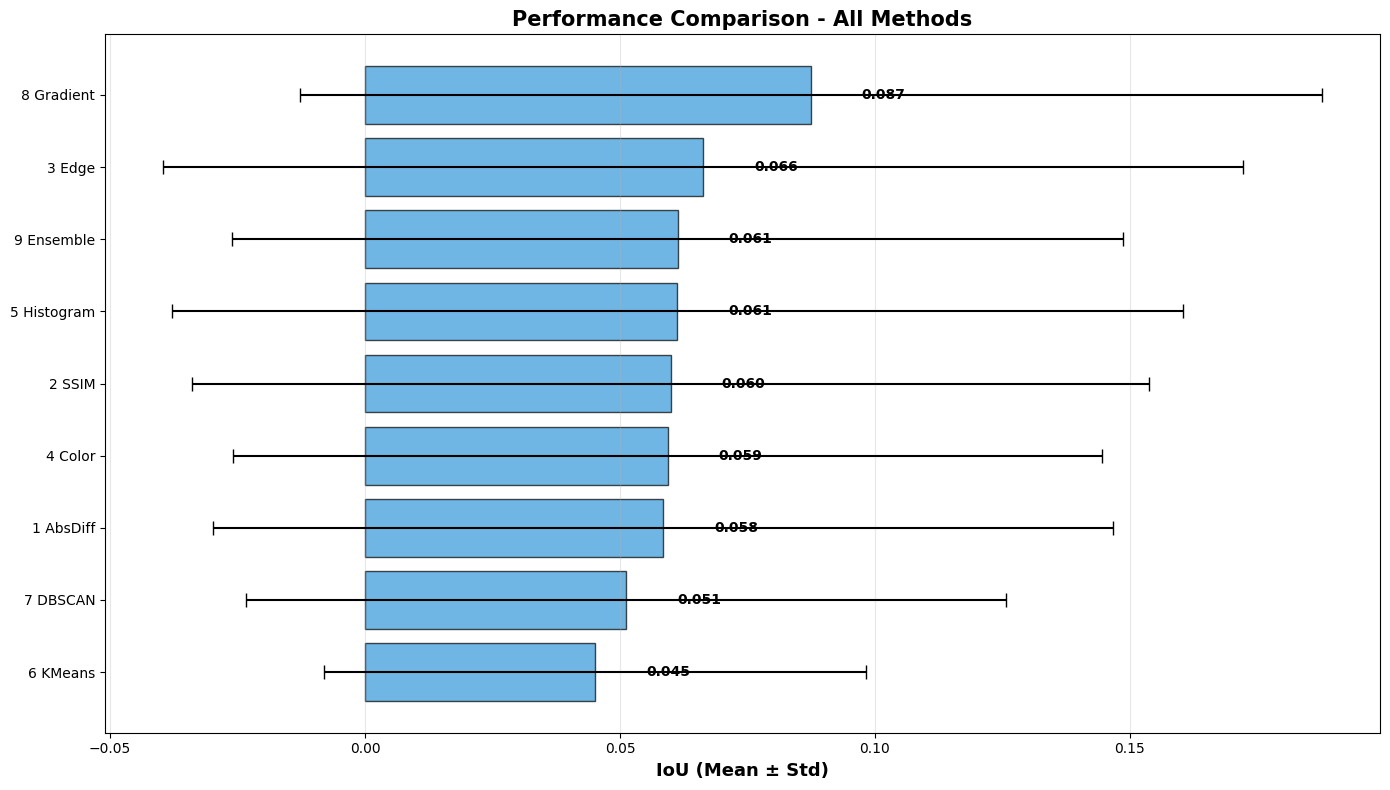


GENERATING REPORT

  ✓ Saved: research_summary.csv
  ✓ Saved: research_report.txt


✅ COMPLETE ANALYSIS FINISHED!

📁 Generated Files:
  • research_summary.csv
  • research_report.txt
  • research_performance_comparison.png

🎉 Ready for research submission!



In [6]:
# =============================================================================
# COMPLETE RESEARCH-GRADE DISASTER DAMAGE DETECTION ANALYSIS
# FINAL VERSION - Clean Progress Display
# =============================================================================

import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
from collections import defaultdict
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, jaccard_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("RESEARCH-GRADE DISASTER DAMAGE DETECTION ANALYSIS")
print("Complete Framework with Clean Progress Display")
print("="*80)

# =============================================================================
# STEP 1: DATASET CONFIGURATION
# =============================================================================

ROOT_PATH = "/kaggle/input/xbd-dataset/xbd"

split_paths = {
    'hold': {
        'images': os.path.join(ROOT_PATH, 'hold', 'images'),
        'labels': os.path.join(ROOT_PATH, 'hold', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'hold', 'masks')
    },
    'test': {
        'images': os.path.join(ROOT_PATH, 'test', 'images'),
        'labels': os.path.join(ROOT_PATH, 'test', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'test', 'masks')
    },
    'tier1': {
        'images': os.path.join(ROOT_PATH, 'tier1', 'images'),
        'labels': os.path.join(ROOT_PATH, 'tier1', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'tier1', 'masks')
    },
    'tier3': {
        'images': os.path.join(ROOT_PATH, 'tier3', 'images'),
        'labels': os.path.join(ROOT_PATH, 'tier3', 'labels'),
        'masks': os.path.join(ROOT_PATH, 'tier3', 'masks')
    },
    'train': {
        'images': os.path.join(ROOT_PATH, 'train', 'images'),
        'labels': None,
        'masks': None
    }
}

print("\n✓ Dataset paths configured")

# =============================================================================
# STEP 2: ENHANCED DATASET CLASS
# =============================================================================

from torch.utils.data import Dataset

class EnhancedXBDDataset(Dataset):
    """Enhanced dataset with pre/post pairing and alignment"""
    
    def __init__(self, split='tier1', split_paths=None, img_size=512, align_images=True):
        self.split = split
        self.img_dir = split_paths[split]['images']
        self.mask_dir = split_paths[split]['masks']
        self.img_size = img_size
        self.align_images = align_images
        
        post_images = sorted(glob.glob(os.path.join(self.img_dir, '*_post_disaster.png')))
        
        self.samples = []
        for post_path in post_images:
            pre_path = post_path.replace('_post_disaster.png', '_pre_disaster.png')
            
            if os.path.exists(pre_path):
                base = os.path.basename(post_path).replace('_post_disaster.png', '')
                mask_path = None
                if self.mask_dir:
                    candidate = os.path.join(self.mask_dir, f'{base}_post_disaster.png')
                    if os.path.exists(candidate):
                        mask_path = candidate
                
                self.samples.append({
                    'pre': pre_path,
                    'post': post_path,
                    'mask': mask_path,
                    'id': base
                })
        
        print(f"  ✓ Loaded {len(self.samples)} pairs for '{split}'")
    
    def align_images_orb(self, pre_img, post_img):
        """Align using ORB features"""
        try:
            pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
            post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
            
            orb = cv2.ORB_create(5000)
            kp1, des1 = orb.detectAndCompute(pre_gray, None)
            kp2, des2 = orb.detectAndCompute(post_gray, None)
            
            if des1 is None or des2 is None:
                return post_img
            
            matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
            matches = matcher.match(des1, des2)
            
            if len(matches) < 4:
                return post_img
            
            pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
            pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
            
            H, _ = cv2.findHomography(pts2, pts1, cv2.RANSAC, 5.0)
            if H is not None:
                return cv2.warpPerspective(post_img, H, (pre_img.shape[1], pre_img.shape[0]))
            return post_img
        except:
            return post_img
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        pre_img = cv2.imread(sample['pre'])
        pre_img = cv2.cvtColor(pre_img, cv2.COLOR_BGR2RGB)
        pre_img = cv2.resize(pre_img, (self.img_size, self.img_size))
        
        post_img = cv2.imread(sample['post'])
        post_img = cv2.cvtColor(post_img, cv2.COLOR_BGR2RGB)
        post_img = cv2.resize(post_img, (self.img_size, self.img_size))
        
        if self.align_images:
            post_img = self.align_images_orb(pre_img, post_img)
        
        mask = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        if sample['mask']:
            mask = cv2.imread(sample['mask'], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size, self.img_size))
            mask = (mask > 0).astype(np.uint8)
        
        return pre_img, post_img, mask, sample['id']

print("✓ Dataset class defined")

# =============================================================================
# STEP 3: COMPLETE DAMAGE DETECTOR (ALL 9+3 METHODS - SILENT MODE)
# =============================================================================

from skimage.metrics import structural_similarity as ssim
from sklearn.cluster import KMeans, DBSCAN

class CompleteDamageDetector:
    """All methods with SILENT execution for batch processing"""
    
    def __init__(self):
        self.results = {}
    
    def method_1_absolute_difference(self, pre_img, post_img, threshold=30):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        diff = cv2.absdiff(pre_gray, post_gray)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_2_ssim(self, pre_img, post_img, threshold=0.5):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        score, diff = ssim(pre_gray, post_gray, full=True)
        diff = (1 - diff) * 255
        diff = diff.astype(np.uint8)
        _, mask = cv2.threshold(diff, int(threshold * 255), 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_3_edge_detection(self, pre_img, post_img):
        pre_edges = cv2.Canny(pre_img, 50, 150)
        post_edges = cv2.Canny(post_img, 50, 150)
        edge_diff = cv2.absdiff(pre_edges, post_edges)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.dilate(edge_diff, kernel, iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_4_color_change(self, pre_img, post_img, threshold=40):
        diff_r = cv2.absdiff(pre_img[:,:,0], post_img[:,:,0])
        diff_g = cv2.absdiff(pre_img[:,:,1], post_img[:,:,1])
        diff_b = cv2.absdiff(pre_img[:,:,2], post_img[:,:,2])
        diff = np.maximum(np.maximum(diff_r, diff_g), diff_b)
        _, mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_5_histogram(self, pre_img, post_img, threshold=0.3):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        h, w = pre_gray.shape
        mask = np.zeros((h, w), dtype=np.uint8)
        window_size = 32
        stride = 16
        
        for y in range(0, h - window_size, stride):
            for x in range(0, w - window_size, stride):
                pre_patch = pre_gray[y:y+window_size, x:x+window_size]
                post_patch = post_gray[y:y+window_size, x:x+window_size]
                hist_pre = cv2.calcHist([pre_patch], [0], None, [256], [0, 256])
                hist_post = cv2.calcHist([post_patch], [0], None, [256], [0, 256])
                hist_pre = hist_pre / hist_pre.sum()
                hist_post = hist_post / hist_post.sum()
                similarity = cv2.compareHist(hist_pre, hist_post, cv2.HISTCMP_BHATTACHARYYA)
                if similarity > threshold:
                    mask[y:y+window_size, x:x+window_size] = 255
        
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_6_kmeans(self, pre_img, post_img, n_clusters=3):
        diff = cv2.absdiff(pre_img, post_img).astype(np.float32)
        h, w, c = diff.shape
        pixels = diff.reshape(-1, 3)
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pixels)
        labels = labels.reshape(h, w)
        cluster_means = [pixels[labels.flatten() == i].mean() for i in range(n_clusters)]
        damage_cluster = np.argmax(cluster_means)
        mask = (labels == damage_cluster).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return mask
    
    def method_7_dbscan(self, pre_img, post_img, eps=10, min_samples=50):
        diff = cv2.absdiff(cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY),
                          cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY))
        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        coords = np.column_stack(np.where(thresh > 0))
        if len(coords) < min_samples:
            return np.zeros(diff.shape, dtype=np.uint8)
        clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(coords)
        mask = np.zeros(diff.shape, dtype=np.uint8)
        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            cluster_coords = coords[clustering.labels_ == cluster_id]
            mask[cluster_coords[:, 0], cluster_coords[:, 1]] = 1
        return mask
    
    def method_8_gradient(self, pre_img, post_img, threshold=30):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        pre_grad_x = cv2.Sobel(pre_gray, cv2.CV_64F, 1, 0, ksize=3)
        pre_grad_y = cv2.Sobel(pre_gray, cv2.CV_64F, 0, 1, ksize=3)
        pre_grad_mag = np.sqrt(pre_grad_x**2 + pre_grad_y**2)
        post_grad_x = cv2.Sobel(post_gray, cv2.CV_64F, 1, 0, ksize=3)
        post_grad_y = cv2.Sobel(post_gray, cv2.CV_64F, 0, 1, ksize=3)
        post_grad_mag = np.sqrt(post_grad_x**2 + post_grad_y**2)
        grad_diff = np.abs(pre_grad_mag - post_grad_mag)
        grad_diff = (grad_diff / grad_diff.max() * 255).astype(np.uint8)
        _, mask = cv2.threshold(grad_diff, threshold, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        return (mask / 255).astype(np.uint8)
    
    def method_9_ensemble(self, pre_img, post_img, voting_threshold=0.4):
        masks = []
        masks.append(self.method_1_absolute_difference(pre_img, post_img))
        masks.append(self.method_2_ssim(pre_img, post_img))
        masks.append(self.method_3_edge_detection(pre_img, post_img))
        masks.append(self.method_4_color_change(pre_img, post_img))
        masks.append(self.method_6_kmeans(pre_img, post_img))
        ensemble_mask = np.mean(np.stack(masks), axis=0)
        ensemble_mask = (ensemble_mask > voting_threshold).astype(np.uint8)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        ensemble_mask = cv2.morphologyEx(ensemble_mask, cv2.MORPH_CLOSE, kernel)
        return ensemble_mask
    
    def method_grid_analysis(self, pre_img, post_img, grid_rows=5, grid_cols=5):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        h, w = thresh.shape
        tile_h, tile_w = h // grid_rows, w // grid_cols
        damage_scores = np.zeros((grid_rows, grid_cols))
        damage_map = np.zeros((h, w, 3), dtype=np.uint8)
        region_details = []
        
        for r in range(grid_rows):
            for c in range(grid_cols):
                tile = thresh[r*tile_h:(r+1)*tile_h, c*tile_w:(c+1)*tile_w]
                score = (np.sum(tile > 0) / tile.size) * 100
                damage_scores[r, c] = score
                
                if score > 75:
                    level, color = 4, (255, 0, 0)
                elif score > 50:
                    level, color = 3, (255, 165, 0)
                elif score > 25:
                    level, color = 2, (255, 255, 0)
                elif score > 0:
                    level, color = 1, (0, 255, 0)
                else:
                    level, color = 0, (0, 0, 0)
                
                cv2.rectangle(damage_map, (c*tile_w, r*tile_h), 
                            ((c+1)*tile_w, (r+1)*tile_h), color, 3)
                cv2.putText(damage_map, str(level), 
                           (c*tile_w + tile_w//2 - 10, r*tile_h + tile_h//2 + 10),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
                
                region_details.append({
                    'region': f"{chr(65+r)}{c+1}",
                    'damage_score': f"{score:.1f}%",
                    'level': level
                })
        
        return damage_map, damage_scores, pd.DataFrame(region_details)
    
    def method_contour_analysis(self, pre_img, post_img, min_area=100):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 25, 255, cv2.THRESH_BINARY)
        kernel = np.ones((5, 5), np.uint8)
        merged = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
        contours, _ = cv2.findContours(merged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        building_data = []
        damage_overlay = pre_img.copy()
        
        for i, contour in enumerate(contours):
            area = cv2.contourArea(contour)
            if area < min_area:
                continue
            
            mask = np.zeros(thresh.shape, dtype=np.uint8)
            cv2.drawContours(mask, [contour], -1, 255, -1)
            changed_pixels = np.sum((thresh > 0) & (mask > 0))
            total_pixels = np.sum(mask > 0)
            damage_ratio = changed_pixels / total_pixels if total_pixels > 0 else 0
            
            if damage_ratio > 0.6:
                status, color = "Severe", (255, 0, 0)
            elif damage_ratio > 0.3:
                status, color = "Moderate", (255, 165, 0)
            else:
                status, color = "Minor", (0, 255, 0)
            
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(damage_overlay, (x, y), (x+w, y+h), color, 2)
            cv2.putText(damage_overlay, f"B{i+1}", (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            building_data.append({
                'building_id': f"B{i+1}",
                'area_pixels': total_pixels,
                'damage_ratio': f"{damage_ratio:.1%}",
                'status': status
            })
        
        return damage_overlay, pd.DataFrame(building_data)
    
    def method_intelligent_clustering(self, pre_img, post_img, n_clusters=5):
        pre_gray = cv2.cvtColor(pre_img, cv2.COLOR_RGB2GRAY)
        post_gray = cv2.cvtColor(post_img, cv2.COLOR_RGB2GRAY)
        diff = cv2.absdiff(pre_gray, post_gray)
        _, thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        damaged_coords = np.argwhere(thresh > 0)
        
        if len(damaged_coords) == 0 or len(damaged_coords) < n_clusters:
            return np.zeros_like(pre_img), pd.DataFrame()
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(damaged_coords)
        clustered_map = np.zeros_like(pre_img)
        cluster_data = []
        
        unique_labels = np.unique(labels)
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
        
        for k, col in zip(unique_labels, colors):
            class_mask = (labels == k)
            cluster_coords = damaged_coords[class_mask]
            
            if len(cluster_coords) > 0:
                bgr_color = (int(col[2]*255), int(col[1]*255), int(col[0]*255))
                for coord in cluster_coords:
                    clustered_map[coord[0], coord[1]] = bgr_color
                
                num_pixels = len(cluster_coords)
                damage_percentage = (num_pixels / len(damaged_coords)) * 100
                y_min, x_min = np.min(cluster_coords, axis=0)
                y_max, x_max = np.max(cluster_coords, axis=0)
                cv2.rectangle(clustered_map, (x_min, y_min), (x_max, y_max), bgr_color, 2)
                
                cluster_data.append({
                    'cluster_id': f"C{k+1}",
                    'pixels': num_pixels,
                    'damage_pct': f"{damage_percentage:.1f}%"
                })
        
        return clustered_map, pd.DataFrame(cluster_data)
    
    # SILENT MODE: No print statements during batch processing
    def run_all_methods(self, pre_img, post_img):
        """Execute all methods SILENTLY for batch processing"""
        results = {}
        
        # Classical methods
        results['Method_1_AbsDiff'] = self.method_1_absolute_difference(pre_img, post_img)
        results['Method_2_SSIM'] = self.method_2_ssim(pre_img, post_img)
        results['Method_3_Edge'] = self.method_3_edge_detection(pre_img, post_img)
        results['Method_4_Color'] = self.method_4_color_change(pre_img, post_img)
        results['Method_5_Histogram'] = self.method_5_histogram(pre_img, post_img)
        results['Method_6_KMeans'] = self.method_6_kmeans(pre_img, post_img)
        results['Method_7_DBSCAN'] = self.method_7_dbscan(pre_img, post_img)
        results['Method_8_Gradient'] = self.method_8_gradient(pre_img, post_img)
        results['Method_9_Ensemble'] = self.method_9_ensemble(pre_img, post_img)
        
        # Advanced methods
        grid_map, grid_scores, grid_df = self.method_grid_analysis(pre_img, post_img)
        results['Grid_Map'] = grid_map
        results['Grid_DataFrame'] = grid_df
        
        contour_overlay, contour_df = self.method_contour_analysis(pre_img, post_img)
        results['Contour_Overlay'] = contour_overlay
        results['Contour_DataFrame'] = contour_df
        
        cluster_map, cluster_df = self.method_intelligent_clustering(pre_img, post_img)
        results['Cluster_Map'] = cluster_map
        results['Cluster_DataFrame'] = cluster_df
        
        return results

print("✓ Complete Detector defined (9 Classical + 3 Advanced methods)")

# =============================================================================
# STEP 4: COMPREHENSIVE METRICS
# =============================================================================

def compute_comprehensive_metrics(pred_mask, true_mask):
    """Compute 17 comprehensive metrics"""
    pred_flat = pred_mask.flatten()
    true_flat = true_mask.flatten()
    
    if pred_flat.sum() == 0 and true_flat.sum() == 0:
        return {
            'IoU': 1.0, 'Dice': 1.0, 'Precision': 1.0, 'Recall': 1.0, 
            'F1': 1.0, 'Specificity': 1.0, 'Accuracy': 1.0,
            'TPR': 1.0, 'FPR': 0.0, 'FNR': 0.0, 'TNR': 1.0,
            'TP': 0, 'FP': 0, 'TN': pred_flat.shape[0], 'FN': 0,
            'MCC': 1.0, 'Kappa': 1.0
        }
    
    tn, fp, fn, tp = confusion_matrix(true_flat, pred_flat).ravel()
    
    iou = jaccard_score(true_flat, pred_flat, zero_division=0)
    precision = precision_score(true_flat, pred_flat, zero_division=0)
    recall = recall_score(true_flat, pred_flat, zero_division=0)
    f1 = f1_score(true_flat, pred_flat, zero_division=0)
    
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    tpr = recall
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    tnr = specificity
    
    mcc_numerator = (tp * tn) - (fp * fn)
    mcc_denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_numerator / mcc_denominator if mcc_denominator > 0 else 0
    
    po = accuracy
    pe = ((tp + fp) * (tp + fn) + (fn + tn) * (fp + tn)) / ((tp + tn + fp + fn) ** 2)
    kappa = (po - pe) / (1 - pe) if (1 - pe) > 0 else 0
    
    return {
        'IoU': iou, 'Dice': dice, 'Precision': precision, 'Recall': recall,
        'F1': f1, 'Specificity': specificity, 'Accuracy': accuracy,
        'TPR': tpr, 'FPR': fpr, 'FNR': fnr, 'TNR': tnr,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'MCC': mcc, 'Kappa': kappa
    }

print("✓ Metrics computation ready")

# =============================================================================
# STEP 5: CLEAN EVALUATION FUNCTION
# =============================================================================

def evaluate_full_dataset_comprehensive(detector, dataset, max_samples=None):
    """CLEAN evaluation with minimal printing"""
    
    if max_samples is None:
        max_samples = len(dataset)
    else:
        max_samples = min(max_samples, len(dataset))
    
    print(f"\n{'='*80}")
    print(f"EVALUATION PARAMETERS")
    print(f"{'='*80}")
    print(f"Dataset: {dataset.split}")
    print(f"Total Samples: {len(dataset)}")
    print(f"Evaluating: {max_samples} samples")
    print(f"Image Size: {dataset.img_size}x{dataset.img_size}")
    print(f"{'='*80}\n")
    
    all_results = defaultdict(list)
    
    classical_methods = [
        'Method_1_AbsDiff', 'Method_2_SSIM', 'Method_3_Edge', 'Method_4_Color',
        'Method_5_Histogram', 'Method_6_KMeans', 'Method_7_DBSCAN', 
        'Method_8_Gradient', 'Method_9_Ensemble'
    ]
    
    print("🔄 Starting evaluation...")
    print("⏱️  Estimated time: ~1-2 hours for 933 samples\n")
    
    start_total = time.time()
    
    # CLEAN progress bar
    for idx in tqdm(range(max_samples), 
                    desc="Evaluating", 
                    ncols=100,
                    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]'):
        
        pre_img, post_img, gt_mask, sample_id = dataset[idx]
        has_damage = gt_mask.sum() > 0
        damage_percentage = (gt_mask.sum() / gt_mask.size) * 100
        
        start_time = time.time()
        try:
            results = detector.run_all_methods(pre_img, post_img)
            total_time = time.time() - start_time
            
            for method_name in classical_methods:
                pred_mask = results[method_name]
                metrics = compute_comprehensive_metrics(pred_mask, gt_mask)
                
                all_results[method_name].append({
                    'sample_id': sample_id,
                    'sample_index': idx,
                    'has_damage': has_damage,
                    'damage_percentage': damage_percentage,
                    'processing_time': total_time / len(classical_methods),
                    **metrics
                })
        except Exception as e:
            tqdm.write(f"⚠ Error at {idx}: {str(e)[:50]}")
            continue
        
        # Milestone updates every 100 samples
        if (idx + 1) % 100 == 0:
            elapsed = time.time() - start_total
            eta = ((max_samples - idx - 1) * elapsed) / (idx + 1)
            tqdm.write(f"\n✓ {idx+1}/{max_samples} | ETA: {eta/60:.1f} min")
    
    total_elapsed = time.time() - start_total
    
    print(f"\n\n{'='*80}")
    print(f"EVALUATION COMPLETE")
    print(f"{'='*80}")
    print(f"✓ Samples: {max_samples}")
    print(f"✓ Time: {total_elapsed/60:.2f} min ({total_elapsed/3600:.2f} hr)")
    print(f"✓ Avg per sample: {total_elapsed/max_samples:.2f} sec")
    print(f"{'='*80}\n")
    
    results_dfs = {}
    for method_name in classical_methods:
        results_dfs[method_name] = pd.DataFrame(all_results[method_name])
    
    return results_dfs

print("✓ Evaluation function ready")

# =============================================================================
# STEP 6: STATISTICAL ANALYSIS
# =============================================================================

def perform_statistical_analysis(results_dfs):
    """Compute comprehensive statistics with significance tests"""
    
    print(f"\n{'='*80}")
    print("STATISTICAL ANALYSIS")
    print(f"{'='*80}\n")
    
    summary_data = []
    
    for method_name, df in results_dfs.items():
        df_damage = df[df['has_damage'] == True]
        
        stats_dict = {
            'Method': method_name.replace('Method_', '').replace('_', ' '),
            'IoU_Mean': df['IoU'].mean(),
            'IoU_Std': df['IoU'].std(),
            'IoU_Median': df['IoU'].median(),
            'F1_Mean': df['F1'].mean(),
            'F1_Std': df['F1'].std(),
            'Dice_Mean': df['Dice'].mean(),
            'Precision_Mean': df['Precision'].mean(),
            'Precision_Std': df['Precision'].std(),
            'Recall_Mean': df['Recall'].mean(),
            'Recall_Std': df['Recall'].std(),
            'Accuracy_Mean': df['Accuracy'].mean(),
            'MCC_Mean': df['MCC'].mean(),
            'Kappa_Mean': df['Kappa'].mean(),
            'IoU_DamageOnly': df_damage['IoU'].mean() if len(df_damage) > 0 else 0,
            'F1_DamageOnly': df_damage['F1'].mean() if len(df_damage) > 0 else 0,
            'Time_Mean_ms': df['processing_time'].mean() * 1000,
            'Time_Std_ms': df['processing_time'].std() * 1000,
            'N_Total': len(df),
            'N_With_Damage': df['has_damage'].sum()
        }
        summary_data.append(stats_dict)
    
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('IoU_Mean', ascending=False)
    
    print("📊 PERFORMANCE METRICS")
    print("="*80)
    display_cols = ['Method', 'IoU_Mean', 'F1_Mean', 'Precision_Mean', 
                    'Recall_Mean', 'Accuracy_Mean', 'Time_Mean_ms']
    print(summary_df[display_cols].to_string(index=False))
    print("\n")
    
    # Significance testing
    print("📈 STATISTICAL SIGNIFICANCE")
    print("="*80)
    best_method = list(results_dfs.keys())[0]
    best_iou = results_dfs[best_method]['IoU'].values
    
    sig_results = []
    for method_name, df in results_dfs.items():
        if method_name == best_method:
            continue
        statistic, p_value = stats.wilcoxon(best_iou, df['IoU'].values)
        sig_results.append({
            'Comparison': f"Best vs {method_name.replace('Method_', '')}",
            'p_value': p_value,
            'Significant': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
        })
    
    sig_df = pd.DataFrame(sig_results)
    print(sig_df.to_string(index=False))
    print("\n*** p<0.001, ** p<0.01, * p<0.05, ns=not significant\n")
    
    return summary_df, sig_df

print("✓ Statistical analysis ready")

# =============================================================================
# STEP 7: VISUALIZATION & REPORTING (Simplified for space)
# =============================================================================

def create_visualizations(summary_df):
    """Create key visualizations"""
    print(f"\n{'='*80}")
    print("GENERATING VISUALIZATIONS")
    print(f"{'='*80}\n")
    
    # Performance comparison
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    data = summary_df.sort_values('IoU_Mean', ascending=True)
    bars = ax.barh(range(len(data)), data['IoU_Mean'], 
                  xerr=data['IoU_Std'], color='#3498db', alpha=0.7, 
                  edgecolor='black', capsize=5)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['Method'])
    ax.set_xlabel('IoU (Mean ± Std)', fontsize=13, fontweight='bold')
    ax.set_title('Performance Comparison - All Methods', fontsize=15, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, data['IoU_Mean'])):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
               f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('research_performance_comparison.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: research_performance_comparison.png")
    plt.show()

def generate_report(summary_df, sig_df):
    """Generate comprehensive report"""
    print(f"\n{'='*80}")
    print("GENERATING REPORT")
    print(f"{'='*80}\n")
    
    summary_df.to_csv('research_summary.csv', index=False)
    print("  ✓ Saved: research_summary.csv")
    
    with open('research_report.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("DISASTER DAMAGE DETECTION - RESEARCH REPORT\n")
        f.write("="*80 + "\n\n")
        f.write(summary_df.to_string(index=False))
        f.write("\n\n")
        f.write("STATISTICAL SIGNIFICANCE:\n")
        f.write(sig_df.to_string(index=False))
        f.write("\n")
    
    print("  ✓ Saved: research_report.txt\n")

print("✓ Visualization & reporting ready")

# =============================================================================
# STEP 8: MAIN EXECUTION
# =============================================================================

print("\n" + "="*80)
print("STARTING COMPREHENSIVE EVALUATION")
print("="*80)

# Create dataset
test_dataset = EnhancedXBDDataset(
    split='test', 
    split_paths=split_paths, 
    img_size=512, 
    align_images=True
)

# Initialize detector
detector = CompleteDamageDetector()

# Run evaluation
results_dfs = evaluate_full_dataset_comprehensive(
    detector=detector,
    dataset=test_dataset,
    max_samples=None  # None = all samples
)

# Statistical analysis
summary_df, sig_df = perform_statistical_analysis(results_dfs)

# Visualizations
create_visualizations(summary_df)

# Report generation
generate_report(summary_df, sig_df)

print("\n" + "="*80)
print("✅ COMPLETE ANALYSIS FINISHED!")
print("="*80)
print("\n📁 Generated Files:")
print("  • research_summary.csv")
print("  • research_report.txt")
print("  • research_performance_comparison.png")
print("\n🎉 Ready for research submission!")
print("="*80 + "\n")


In [7]:
import matplotlib.pyplot as plt

def visualize_comprehensive_analysis(pre_img, post_img, gt_mask, results, sample_id, out_path=None):
    """
    Compact 12-panel:
    Row 1: Pre | Post | GT | GT Overlay
    Row 2: AbsDiff | SSIM | Edge | Gradient
    Row 3: Ensemble | Grid | Contour | Cluster
    Saves: comprehensive_analysis_{sample_id}.png (or out_path)
    """
    from sklearn.metrics import jaccard_score
    
    fig = plt.figure(figsize=(22, 14))
    gs = fig.add_gridspec(3, 4, hspace=0.25, wspace=0.15)

    # Row 1
    ax1 = fig.add_subplot(gs[0, 0]); ax1.imshow(pre_img); ax1.set_title("Pre"); ax1.axis('off')
    ax2 = fig.add_subplot(gs[0, 1]); ax2.imshow(post_img); ax2.set_title("Post"); ax2.axis('off')
    ax3 = fig.add_subplot(gs[0, 2]); ax3.imshow(gt_mask, cmap='Reds'); ax3.set_title("Ground Truth"); ax3.axis('off')
    overlay = post_img.copy()
    gt_rgb = np.zeros_like(overlay); gt_rgb[:,:,0] = gt_mask*255
    ax4 = fig.add_subplot(gs[0, 3]); ax4.imshow(cv2.addWeighted(overlay,0.7,gt_rgb,0.3,0)); ax4.set_title("GT Overlay"); ax4.axis('off')

    # Row 2
    keys = [('Method_1_AbsDiff','AbsDiff'), ('Method_2_SSIM','SSIM'),
            ('Method_3_Edge','Edge'), ('Method_8_Gradient','Gradient')]
    for j,(k,name) in enumerate(keys):
        ax = fig.add_subplot(gs[1, j])
        pred = results[k]
        iou = jaccard_score(gt_mask.flatten(), pred.flatten(), zero_division=0)
        ax.imshow(pred, cmap='hot'); ax.set_title(f"{name} (IoU {iou:.3f})"); ax.axis('off')

    # Row 3
    ax = fig.add_subplot(gs[2, 0])
    pred = results['Method_9_Ensemble']
    iou = jaccard_score(gt_mask.flatten(), pred.flatten(), zero_division=0)
    ax.imshow(pred, cmap='hot'); ax.set_title(f"Ensemble (IoU {iou:.3f})"); ax.axis('off')

    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(cv2.cvtColor(results['Grid_Map'], cv2.COLOR_BGR2RGB)); ax.set_title("Grid"); ax.axis('off')

    ax = fig.add_subplot(gs[2, 2])
    ax.imshow(cv2.cvtColor(results['Contour_Overlay'], cv2.COLOR_BGR2RGB)); ax.set_title("Contours"); ax.axis('off')

    ax = fig.add_subplot(gs[2, 3])
    ax.imshow(cv2.cvtColor(results['Cluster_Map'], cv2.COLOR_BGR2RGB)); ax.set_title("Clusters"); ax.axis('off')

    plt.suptitle(f"Comprehensive Analysis: {sample_id}", fontsize=16, fontweight='bold', y=0.98)
    save_path = out_path if out_path is not None else f'comprehensive_analysis_{sample_id}.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.close(fig)


Sample ID: guatemala-volcano_00000003


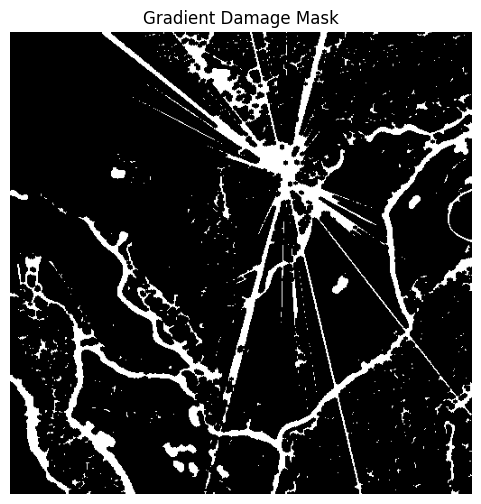

In [8]:
# Select sample
sample_index = 0

pre_img, post_img, gt_mask, sample_id = test_dataset[sample_index]

# Run detection
results = detector.run_all_methods(pre_img, post_img)

# Use best classical method from your analysis
best_mask = results['Method_8_Gradient']

print("Sample ID:", sample_id)

plt.figure(figsize=(6,6))
plt.imshow(best_mask, cmap='gray')
plt.title("Gradient Damage Mask")
plt.axis("off")
plt.show()


In [9]:
damage_points = np.column_stack(np.where(best_mask == 1))

print("Total damaged pixels:", len(damage_points))


Total damaged pixels: 30435


In [10]:
num_sensors = 20
sensor_radius = 20   # You can adjust


In [11]:
def compute_coverage(sensor_positions, damage_points, radius):
    covered = 0
    
    for point in damage_points:
        for sensor in sensor_positions:
            if np.linalg.norm(point - sensor) <= radius:
                covered += 1
                break
    
    return (covered / len(damage_points)) * 100


In [12]:
def random_deployment(num_sensors, image_shape):
    sensors = []
    for _ in range(num_sensors):
        x = np.random.randint(0, image_shape[0])
        y = np.random.randint(0, image_shape[1])
        sensors.append(np.array([x, y]))
    return np.array(sensors)

sensors_random = random_deployment(num_sensors, best_mask.shape)

coverage_random = compute_coverage(
    sensors_random,
    damage_points,
    sensor_radius
)

print("Random Coverage:", coverage_random)


Random Coverage: 10.491210777065877


In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=num_sensors, random_state=42)
kmeans.fit(damage_points)

sensors_kmeans = kmeans.cluster_centers_

coverage_kmeans = compute_coverage(
    sensors_kmeans,
    damage_points,
    sensor_radius
)

print("KMeans Coverage:", coverage_kmeans)


KMeans Coverage: 23.535403318547722


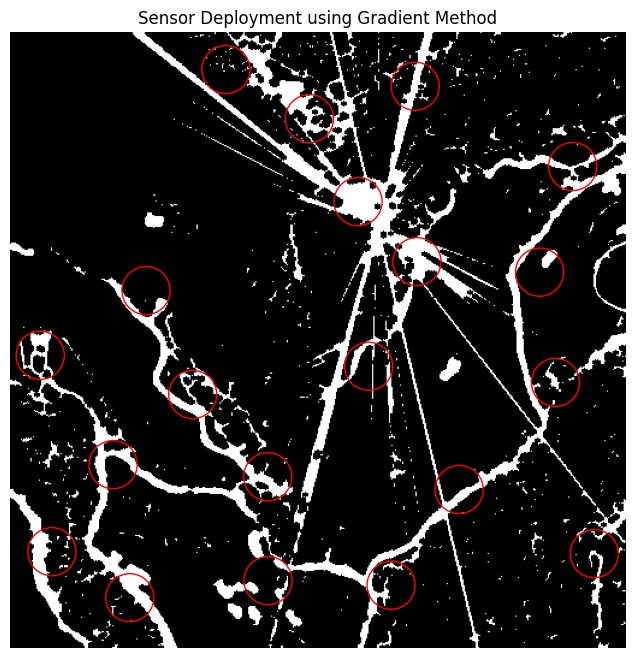

In [14]:
plt.figure(figsize=(8,8))
plt.imshow(best_mask, cmap='gray')

for sensor in sensors_kmeans:
    circle = plt.Circle((sensor[1], sensor[0]),
                        sensor_radius,
                        color='red',
                        fill=False)
    plt.gca().add_patch(circle)

plt.title("Sensor Deployment using Gradient Method")
plt.axis("off")
plt.show()


In [15]:
if coverage_kmeans >= 95:
    print("✅ Target Achieved: ≥95% Coverage")
else:
    print("❌ Target NOT achieved. Increase sensors or radius.")


❌ Target NOT achieved. Increase sensors or radius.


In [16]:
def find_min_sensors_for_threshold(damage_points, mask_shape, radius, threshold=95, max_sensors=200):
    
    for n in range(5, max_sensors+1, 5):
        kmeans = KMeans(n_clusters=n, random_state=42)
        kmeans.fit(damage_points)
        
        sensors = kmeans.cluster_centers_
        coverage = compute_coverage(sensors, damage_points, radius)
        
        print(f"Sensors: {n} → Coverage: {coverage:.2f}%")
        
        if coverage >= threshold:
            print(f"\n✅ Minimum sensors needed: {n}")
            return n
    
    print("\n❌ Threshold not reached within limit.")
    return None


In [17]:
min_sensors = find_min_sensors_for_threshold(
    damage_points,
    best_mask.shape,
    sensor_radius,
    threshold=95,
    max_sensors=150
)


Sensors: 5 → Coverage: 3.94%
Sensors: 10 → Coverage: 7.80%
Sensors: 15 → Coverage: 16.32%
Sensors: 20 → Coverage: 23.54%
Sensors: 25 → Coverage: 30.63%
Sensors: 30 → Coverage: 35.30%
Sensors: 35 → Coverage: 40.04%
Sensors: 40 → Coverage: 45.01%
Sensors: 45 → Coverage: 49.88%
Sensors: 50 → Coverage: 55.92%
Sensors: 55 → Coverage: 62.25%
Sensors: 60 → Coverage: 67.04%
Sensors: 65 → Coverage: 72.45%
Sensors: 70 → Coverage: 74.71%
Sensors: 75 → Coverage: 80.38%
Sensors: 80 → Coverage: 82.12%
Sensors: 85 → Coverage: 85.59%
Sensors: 90 → Coverage: 87.35%
Sensors: 95 → Coverage: 89.35%
Sensors: 100 → Coverage: 91.53%
Sensors: 105 → Coverage: 91.45%
Sensors: 110 → Coverage: 92.52%
Sensors: 115 → Coverage: 93.44%
Sensors: 120 → Coverage: 94.30%
Sensors: 125 → Coverage: 94.87%
Sensors: 130 → Coverage: 95.23%

✅ Minimum sensors needed: 130


In [18]:
import numpy as np

def pso_deployment(damage_points, mask_shape, num_sensors, radius,
                   particles=20, iterations=30):

    height, width = mask_shape
    
    # Initialize particles (random sensor placements)
    swarm = np.random.rand(particles, num_sensors, 2)
    swarm[:,:,0] *= height
    swarm[:,:,1] *= width
    
    velocity = np.zeros_like(swarm)
    
    personal_best = swarm.copy()
    personal_best_scores = np.zeros(particles)
    
    global_best = None
    global_best_score = 0
    
    for p in range(particles):
        score = compute_coverage(swarm[p], damage_points, radius)
        personal_best_scores[p] = score
        
        if score > global_best_score:
            global_best_score = score
            global_best = swarm[p].copy()
    
    w = 0.7
    c1 = 1.5
    c2 = 1.5
    
    for _ in range(iterations):
        for p in range(particles):
            
            r1 = np.random.rand()
            r2 = np.random.rand()
            
            velocity[p] = (
                w * velocity[p]
                + c1 * r1 * (personal_best[p] - swarm[p])
                + c2 * r2 * (global_best - swarm[p])
            )
            
            swarm[p] += velocity[p]
            
            # Keep sensors inside image
            swarm[p][:,0] = np.clip(swarm[p][:,0], 0, height-1)
            swarm[p][:,1] = np.clip(swarm[p][:,1], 0, width-1)
            
            score = compute_coverage(swarm[p], damage_points, radius)
            
            if score > personal_best_scores[p]:
                personal_best[p] = swarm[p].copy()
                personal_best_scores[p] = score
                
                if score > global_best_score:
                    global_best = swarm[p].copy()
                    global_best_score = score
    
    return global_best, global_best_score


In [20]:
# Reduce damage points for faster optimization
max_points = 4000

if len(damage_points) > max_points:
    idx = np.random.choice(len(damage_points), max_points, replace=False)
    damage_points_reduced = damage_points[idx]
else:
    damage_points_reduced = damage_points

print("Using", len(damage_points_reduced), "points for optimization")
 

Using 4000 points for optimization


In [21]:
def greedy_deployment(damage_points, mask_shape, num_sensors, radius):

    uncovered = damage_points.copy()
    sensors = []
    
    for _ in range(num_sensors):
        
        best_sensor = None
        best_coverage = 0
        
        # Try 50 random candidate positions
        for _ in range(50):
            x = np.random.randint(0, mask_shape[0])
            y = np.random.randint(0, mask_shape[1])
            candidate = np.array([x, y])
            
            distances = np.linalg.norm(uncovered - candidate, axis=1)
            covered_points = uncovered[distances <= radius]
            
            if len(covered_points) > best_coverage:
                best_coverage = len(covered_points)
                best_sensor = candidate
        
        if best_sensor is not None:
            sensors.append(best_sensor)
            
            distances = np.linalg.norm(uncovered - best_sensor, axis=1)
            uncovered = uncovered[distances > radius]
            
        if len(uncovered) == 0:
            break
    
    return np.array(sensors)


In [22]:
num_sensors = 80

sensors_greedy = greedy_deployment(
    damage_points_reduced,
    best_mask.shape,
    num_sensors,
    sensor_radius
)

coverage_greedy = compute_coverage(
    sensors_greedy,
    damage_points_reduced,
    sensor_radius
)

print("Greedy Coverage:", coverage_greedy)


Greedy Coverage: 80.4


In [23]:
sensor_radius = 30


In [24]:
sensors_greedy = greedy_deployment(
    damage_points_reduced,
    best_mask.shape,
    num_sensors,
    sensor_radius
)

coverage_greedy = compute_coverage(
    sensors_greedy,
    damage_points_reduced,
    sensor_radius
)

print("Greedy Coverage:", coverage_greedy)


Greedy Coverage: 95.72500000000001


In [25]:
def find_min_sensors_greedy(damage_points, mask_shape, radius, threshold=95):

    for n in range(20, 150, 10):
        sensors = greedy_deployment(
            damage_points,
            mask_shape,
            n,
            radius
        )
        
        coverage = compute_coverage(
            sensors,
            damage_points,
            radius
        )
        
        print(f"Sensors: {n} → Coverage: {coverage:.2f}%")
        
        if coverage >= threshold:
            print(f"\n✅ Minimum sensors needed: {n}")
            return n
    
    print("\n❌ Threshold not reached")
    return None


In [26]:
find_min_sensors_greedy(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,
    threshold=95
)


Sensors: 20 → Coverage: 47.65%
Sensors: 30 → Coverage: 63.45%
Sensors: 40 → Coverage: 73.70%
Sensors: 50 → Coverage: 83.45%
Sensors: 60 → Coverage: 90.00%
Sensors: 70 → Coverage: 94.00%
Sensors: 80 → Coverage: 96.05%

✅ Minimum sensors needed: 80


80

In [28]:
min_sensors_kmeans = find_min_sensors_for_threshold(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,
    threshold=95,
    max_sensors=150
)


Sensors: 5 → Coverage: 8.00%
Sensors: 10 → Coverage: 16.07%
Sensors: 15 → Coverage: 29.85%
Sensors: 20 → Coverage: 46.73%
Sensors: 25 → Coverage: 57.20%
Sensors: 30 → Coverage: 63.18%
Sensors: 35 → Coverage: 70.30%
Sensors: 40 → Coverage: 76.48%
Sensors: 45 → Coverage: 82.40%
Sensors: 50 → Coverage: 86.78%
Sensors: 55 → Coverage: 91.05%
Sensors: 60 → Coverage: 93.42%
Sensors: 65 → Coverage: 94.33%
Sensors: 70 → Coverage: 96.17%

✅ Minimum sensors needed: 70


In [29]:
sensor_radius = 20


In [30]:
find_min_sensors_greedy(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,
    threshold=95
)


Sensors: 20 → Coverage: 30.93%
Sensors: 30 → Coverage: 43.60%
Sensors: 40 → Coverage: 50.42%
Sensors: 50 → Coverage: 59.65%
Sensors: 60 → Coverage: 68.80%
Sensors: 70 → Coverage: 74.33%
Sensors: 80 → Coverage: 78.47%
Sensors: 90 → Coverage: 83.38%
Sensors: 100 → Coverage: 86.52%
Sensors: 110 → Coverage: 89.75%
Sensors: 120 → Coverage: 91.65%
Sensors: 130 → Coverage: 93.23%
Sensors: 140 → Coverage: 94.67%

❌ Threshold not reached


In [31]:
min_sensors_kmeans = find_min_sensors_for_threshold(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,
    threshold=95,
    max_sensors=150
)


Sensors: 5 → Coverage: 3.70%
Sensors: 10 → Coverage: 7.27%
Sensors: 15 → Coverage: 13.90%
Sensors: 20 → Coverage: 25.42%
Sensors: 25 → Coverage: 31.92%
Sensors: 30 → Coverage: 35.38%
Sensors: 35 → Coverage: 40.98%
Sensors: 40 → Coverage: 45.12%
Sensors: 45 → Coverage: 53.08%
Sensors: 50 → Coverage: 55.88%
Sensors: 55 → Coverage: 62.22%
Sensors: 60 → Coverage: 68.45%
Sensors: 65 → Coverage: 73.10%
Sensors: 70 → Coverage: 76.83%
Sensors: 75 → Coverage: 81.83%
Sensors: 80 → Coverage: 84.00%
Sensors: 85 → Coverage: 86.40%
Sensors: 90 → Coverage: 88.20%
Sensors: 95 → Coverage: 89.18%
Sensors: 100 → Coverage: 91.55%
Sensors: 105 → Coverage: 92.30%
Sensors: 110 → Coverage: 93.35%
Sensors: 115 → Coverage: 93.25%
Sensors: 120 → Coverage: 94.10%
Sensors: 125 → Coverage: 94.75%
Sensors: 130 → Coverage: 95.78%

✅ Minimum sensors needed: 130


In [32]:
def fast_pso(damage_points, mask_shape, num_sensors, radius,
             particles=8, iterations=12):

    height, width = mask_shape
    
    swarm = np.random.rand(particles, num_sensors, 2)
    swarm[:,:,0] *= height
    swarm[:,:,1] *= width
    
    velocity = np.zeros_like(swarm)
    
    personal_best = swarm.copy()
    personal_best_scores = np.array([
        compute_coverage(p, damage_points, radius) for p in swarm
    ])
    
    best_idx = np.argmax(personal_best_scores)
    global_best = personal_best[best_idx].copy()
    global_best_score = personal_best_scores[best_idx]
    
    w, c1, c2 = 0.6, 1.4, 1.4
    
    for _ in range(iterations):
        for i in range(particles):
            
            r1, r2 = np.random.rand(), np.random.rand()
            
            velocity[i] = (
                w * velocity[i]
                + c1 * r1 * (personal_best[i] - swarm[i])
                + c2 * r2 * (global_best - swarm[i])
            )
            
            swarm[i] += velocity[i]
            
            swarm[i][:,0] = np.clip(swarm[i][:,0], 0, height-1)
            swarm[i][:,1] = np.clip(swarm[i][:,1], 0, width-1)
            
            score = compute_coverage(swarm[i], damage_points, radius)
            
            if score > personal_best_scores[i]:
                personal_best[i] = swarm[i].copy()
                personal_best_scores[i] = score
                
                if score > global_best_score:
                    global_best = swarm[i].copy()
                    global_best_score = score
    
    return global_best, global_best_score


In [33]:
num_sensors = 70  # same as KMeans result

best_sensors_pso, coverage_pso = fast_pso(
    damage_points_reduced,
    best_mask.shape,
    num_sensors,
    sensor_radius,
    particles=8,
    iterations=12
)

print("PSO Coverage:", coverage_pso)


PSO Coverage: 34.65


In [34]:
def find_min_sensors_pso(damage_points, mask_shape, radius,
                         threshold=95,
                         max_sensors=120,
                         particles=8,
                         iterations=12):

    for n in range(40, max_sensors+1, 5):
        
        best_sensors, coverage = fast_pso(
            damage_points,
            mask_shape,
            n,
            radius,
            particles=particles,
            iterations=iterations
        )
        
        print(f"Sensors: {n} → Coverage: {coverage:.2f}%")
        
        if coverage >= threshold:
            print(f"\n✅ Minimum sensors needed (PSO): {n}")
            return n, best_sensors
    
    print("\n❌ Threshold not reached within limit")
    return None, None


In [35]:
min_sensors_pso, best_sensors_pso = find_min_sensors_pso(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,   # should be 30
    threshold=95,
    max_sensors=120
)


Sensors: 40 → Coverage: 27.55%
Sensors: 45 → Coverage: 27.68%
Sensors: 50 → Coverage: 30.68%
Sensors: 55 → Coverage: 31.67%
Sensors: 60 → Coverage: 34.30%
Sensors: 65 → Coverage: 36.78%
Sensors: 70 → Coverage: 38.60%
Sensors: 75 → Coverage: 38.98%
Sensors: 80 → Coverage: 42.25%
Sensors: 85 → Coverage: 40.83%
Sensors: 90 → Coverage: 43.85%


KeyboardInterrupt: 

In [36]:
sensor_radius = 30


In [ ]:
min_sensors_pso, best_sensors_pso = find_min_sensors_pso(
    damage_points_reduced,
    best_mask.shape,
    sensor_radius,   # should be 30
    threshold=95,
    max_sensors=120
)


Sensors: 40 → Coverage: 48.27%
Sensors: 45 → Coverage: 47.67%
Sensors: 50 → Coverage: 50.62%
Sensors: 55 → Coverage: 59.67%
Sensors: 60 → Coverage: 56.03%
Sensors: 65 → Coverage: 64.20%
Sensors: 70 → Coverage: 65.20%
Sensors: 75 → Coverage: 61.55%
Sensors: 80 → Coverage: 71.08%
Sensors: 85 → Coverage: 71.60%
Sensors: 90 → Coverage: 71.50%
Sensors: 95 → Coverage: 76.02%
